# NB03 — Machine Learning Benchmarking: Microbial Source Prediction
**Pipeline:** Generalised Metabolite–Metagenomics Correlation Study  
**Inputs:** `analysis_results.pkl` (from NB02)  
**Outputs:** `ml_results.pkl`, benchmark tables, SHAP figures  
**Cohort:** YACHIDA-CRC-2019 only (stage-stratified CV)  
**Models:** XGBoost · LightGBM · ElasticNet · SVR · Random Forest  

| Step | Analysis |
|---|---|
| 1–2 | Setup, load data |
| 3 | Select top dysregulated metabolite targets |
| 3b | Early vs advanced dysregulation visualisation |
| 4 | Feature matrix: species CLR + clinical confounders (one-hot encoded) |
| 5 | Model definitions (5 models with fallback) |
| 6 | 10-fold stratified CV benchmark — R², Spearman rho, RMSE |
| 7 | Best model selection + benchmark heatmap |
| 8 | SHAP beeswarm (all models, top targets) |
| 9 | SHAP waterfall (per-sample explanation, top targets) |
| 10 | SHAP producer candidate table |
| 10b | Polyamine-focused source attribution |
| 11 | Confounder variance attribution (R² species-only vs full) |
| 12 | Save results |

## 1 · Setup

In [1]:
import sys, warnings, math
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path(".").resolve()))

from utils import (
    INTER_DIR, FIG_DIR, TABLE_DIR,
    DATASET_PRIMARY, FDR_THRESHOLD, N_TOP_TARGETS,
    annotate_pathway,
    load_pickle, save_pickle, savefig,
    PALETTE_STAGE6, PALETTE_3GROUP,
    load_multi_cohort_lodo, DATASETS_LODO, IBD_COHORTS,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.base import clone as sk_clone
from statsmodels.stats.multitest import multipletests

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available — install with: pip install shap")

ana = load_pickle(INTER_DIR / "analysis_results.pkl")

sp_clr = ana["spe"]       # CLR species (YACHIDA, feature-selected)
mt_log = ana["mtb"]       # log10+centred metabolites
meta_y = ana["meta_yk"]
nm_y   = ana["nm_y"]

# Sanitise name map: replace NaN/float values with the KEGG ID string
nm_y = {k: (v if isinstance(v, str) else k) for k, v in nm_y.items()}

for d in [FIG_DIR/"ml", TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Loaded: {sp_clr.shape[1]} species features, {mt_log.shape[1]} metabolite targets")
print(f"Top target count: {N_TOP_TARGETS}")

Loaded: E:\D.Ani\Academic\KI\Results\intermediate\analysis_results.pkl
Loaded: 500 species features, 150 metabolite targets
Top target count: 50


In [2]:
# ── Multi-cohort LODO setup ───────────────────────────────────────────────────
# load_multi_cohort_lodo returns (X, y, groups) across all LODO cohorts in pkl.
# Falls back gracefully if only YACHIDA is present.
pkl_full = load_pickle(INTER_DIR / 'preprocessed_data.pkl')
try:
    X_lodo, y_lodo, lodo_groups = load_multi_cohort_lodo(
        pkl_full, cohorts=None, top_species=300)

    print('LODO cohort composition:')
    print(lodo_groups.value_counts().to_string())
    print(f'\nCommon species features: {X_lodo.shape[1]}')
    print(f'Total samples: {len(X_lodo)}')
    print(f'\nStage.3Group distribution:')
    print(y_lodo.value_counts())

    le_lodo    = LabelEncoder()
    y_lodo_enc = le_lodo.fit_transform(y_lodo.fillna('Healthy'))
    groups_arr = lodo_groups.values
    X_lodo_arr = X_lodo.values.astype(float)
    N_DATASETS = lodo_groups.nunique()

except (ValueError, KeyError) as _e:
    print(f'LODO setup failed: {_e}')
    print('Falling back to within-YACHIDA 10-fold CV.')
    X_lodo_arr = None
    N_DATASETS = 1


Loaded: E:\D.Ani\Academic\KI\Results\intermediate\preprocessed_data.pkl
LODO matrix: 347 samples × 300 species from 1 cohorts
LODO cohort composition:
cohort
YACHIDA-CRC-2019    347

Common species features: 300
Total samples: 347

Stage.3Group distribution:
Stage.3Group
Advanced_CRC    163
Healthy         127
Early_CRC        57
Name: count, dtype: int64


---
## 2 · Top Dysregulated Metabolite Targets
Union of top dysregulated metabolites by |effect_size| from CRC vs Healthy (early + advanced).

In [3]:
da_early = ana["da_mtb"].get("Healthy_vs_Early_CRC",    pd.DataFrame())
da_adv   = ana["da_mtb"].get("Healthy_vs_Advanced_CRC", pd.DataFrame())

def top_n_sig(da_df, n):
    """Return top-n features by |effect_size|, preferring q<0.05."""
    if da_df.empty or "qval" not in da_df.columns:
        return []
    sig = da_df[da_df["qval"] <= FDR_THRESHOLD].copy()
    if len(sig) < n:
        sig = da_df.copy()   # relax if too few pass FDR
    sig["abs_effect"] = sig["effect_size"].abs()
    return sig.nlargest(n, "abs_effect")["feature"].tolist()

early_targets = top_n_sig(da_early, N_TOP_TARGETS)
adv_targets   = top_n_sig(da_adv,   N_TOP_TARGETS)

# Union preserving order (early first)
all_targets = list(dict.fromkeys(early_targets + adv_targets))

# Fallback: use top partial-correlation metabolites
if len(all_targets) < 5 and not ana["corr_partial_sig"].empty:
    from collections import Counter
    counts      = Counter(ana["corr_partial_sig"]["metabolite"])
    all_targets = [m for m, _ in counts.most_common(N_TOP_TARGETS)]

all_targets = [t for t in all_targets if t in mt_log.columns][:N_TOP_TARGETS]

print(f"Targets selected: {len(all_targets)} dysregulated metabolites")
print(f"\nFirst {min(10, len(all_targets))}:")
for t in all_targets[:10]:
    row = da_adv[da_adv["feature"] == t] if not da_adv.empty else pd.DataFrame()
    eff = row["effect_size"].values[0] if not row.empty else float("nan")
    q   = row["qval"].values[0]        if not row.empty else float("nan")
    print(f"  {t}  ({nm_y.get(t,'unknown'):<35})  effect={eff:.3f}  q={q:.3e}")

# Save target list with significance flag
def _is_sig(kegg_id):
    """Check if a target is FDR-significant in either early or advanced DA."""
    for da in [da_early, da_adv]:
        if not da.empty and "qval" in da.columns:
            row = da.loc[da["feature"] == kegg_id, "qval"]
            if not row.empty and (row.values[0] <= FDR_THRESHOLD):
                return True
    return False

target_df = pd.DataFrame({
    "kegg_id":     all_targets,
    "name":        [nm_y.get(t, t) for t in all_targets],
    "pathway":     [annotate_pathway(t) for t in all_targets],
    "significant": [_is_sig(t) for t in all_targets],
})
target_df.to_csv(TABLE_DIR / "ml_target_metabolites.csv", index=False)

n_sig = target_df["significant"].sum()
print(f"\n  FDR-significant: {n_sig}/{len(target_df)}")
if n_sig < len(target_df):
    print(f"  Note: {len(target_df) - n_sig} targets selected by effect-size rank (FDR > 0.05)")

Targets selected: 45 dysregulated metabolites

First 10:
  C07151_Metformin  (C07151                             )  effect=-0.122  q=2.851e-01
  C00423_trans-Cinnamate  (C00423                             )  effect=0.072  q=5.174e-01
  C00122_Fumarate  (C00122                             )  effect=-0.160  q=1.523e-01
  C01042_N-Acetylaspartate  (C01042                             )  effect=-0.106  q=3.179e-01
  C01959_Taurocyamine  (C01959                             )  effect=-0.076  q=4.885e-01
  C08262_Isovalerate  (C08262                             )  effect=-0.166  q=1.461e-01
  C00024_Acetyl CoA  (C00024                             )  effect=0.063  q=5.675e-01
  C00346_Ethanolamine phosphate  (C00346                             )  effect=-0.142  q=2.070e-01
  C01879_5-Oxoproline  (C01879                             )  effect=-0.013  q=9.158e-01
  C16741_5-Hydroxylysine  (C16741                             )  effect=0.112  q=3.086e-01

  FDR-significant: 8/45
  Note: 37 targets s

### Early vs Advanced Dysregulation Profile
Grouped bar chart comparing effect sizes for the selected targets across early-stage and advanced-stage CRC vs Healthy.

In [4]:
# Merge early and advanced effect sizes for selected targets
viz_df = pd.DataFrame({"target": all_targets})
if not da_early.empty:
    viz_df = viz_df.merge(
        da_early[["feature", "effect_size", "qval"]].rename(
            columns={"feature": "target", "effect_size": "early_effect", "qval": "early_q"}),
        on="target", how="left")
else:
    viz_df["early_effect"] = float("nan")
    viz_df["early_q"] = float("nan")

if not da_adv.empty:
    viz_df = viz_df.merge(
        da_adv[["feature", "effect_size", "qval"]].rename(
            columns={"feature": "target", "effect_size": "adv_effect", "qval": "adv_q"}),
        on="target", how="left")
else:
    viz_df["adv_effect"] = float("nan")
    viz_df["adv_q"] = float("nan")

viz_df["name"] = viz_df["target"].map(nm_y)
viz_df = viz_df.sort_values("adv_effect", ascending=True, na_position="first")

# Grouped horizontal bar chart
fig, ax = plt.subplots(figsize=(10, max(5, len(viz_df) * 0.4)))
y_pos = np.arange(len(viz_df))
bar_h = 0.35
ax.barh(y_pos - bar_h / 2, viz_df["early_effect"].fillna(0), bar_h,
        label="Early CRC vs Healthy", color="#66BB6A", edgecolor="white", lw=0.5)
ax.barh(y_pos + bar_h / 2, viz_df["adv_effect"].fillna(0), bar_h,
        label="Advanced CRC vs Healthy", color="#EF5350", edgecolor="white", lw=0.5)

# Mark FDR-significant bars with asterisk
for i, (_, row) in enumerate(viz_df.iterrows()):
    if pd.notna(row.get("early_q")) and row["early_q"] <= FDR_THRESHOLD:
        ax.text(row["early_effect"] + 0.005, i - bar_h / 2, "*", va="center", fontsize=10)
    if pd.notna(row.get("adv_q")) and row["adv_q"] <= FDR_THRESHOLD:
        ax.text(row["adv_effect"] + 0.005, i + bar_h / 2, "*", va="center", fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(viz_df["name"].str[:40], fontsize=8)
ax.set_xlabel("Effect size (rank-biserial r)")
ax.set_title("Dysregulated Metabolites: Early vs Advanced CRC", fontweight="bold")
ax.legend(loc="lower right")
ax.axvline(0, color="black", lw=0.5)
plt.tight_layout()
savefig(fig, "ml", "nb03_early_vs_advanced_dysregulation.png")
print("Saved: nb03_early_vs_advanced_dysregulation.png")

Saved figure: E:\D.Ani\Academic\KI\Results\figures\ml\nb03_early_vs_advanced_dysregulation.pdf
Saved: nb03_early_vs_advanced_dysregulation.png


> **B6 — Polyamine Absence from ML Targets (Publication Disclosure)**
> Polyamine species (putrescine C00134, spermidine C00315, spermine C00750) are absent
> from the top-50 dysregulated ML targets due to modest effect sizes in this cohort.
> Polyamine source attribution in NB07 derives from partial-correlation SHAP (E1 stream),
> not regression targets, and should be treated as hypothesis-generating.

---
## 3 · Feature Matrix & Confounders

In [5]:
conf_cols  = ["Age", "BMI", "Gender", "Alcohol", "Tumor location"]
avail_conf = [c for c in conf_cols if c in meta_y.columns]

X_species = sp_clr.copy()

# ── Stage one-hot dummies (Healthy = reference) ───────────────────────────────
# Including disease stage as a model feature allows the ML to capture
# stage-correlated metabolite variance and improves SHAP producer attribution.
_stage_col = "Stage.3Group"
if _stage_col in meta_y.columns:
    _stage_dummies = pd.get_dummies(meta_y[_stage_col], drop_first=False, dtype=float)
    _stage_keep    = [c for c in _stage_dummies.columns if c != "Healthy"]
    stage_dummies  = _stage_dummies[_stage_keep].rename(columns=lambda c: f"stage_{c}")
else:
    stage_dummies = pd.DataFrame(index=meta_y.index)
    _stage_keep   = []

if avail_conf:
    cov = meta_y[avail_conf].copy()
    cat_cols = cov.select_dtypes("object").columns.tolist()
    if cat_cols:
        cov = pd.get_dummies(cov, columns=cat_cols, drop_first=True, dtype=float)
    if not stage_dummies.empty:
        cov = pd.concat([cov, stage_dummies], axis=1)
    X_full = pd.concat([X_species, cov], axis=1)
    conf_col_indices = [X_full.columns.get_loc(c) for c in cov.columns]
else:
    if not stage_dummies.empty:
        X_full = pd.concat([X_species, stage_dummies], axis=1)
        conf_col_indices = [X_full.columns.get_loc(c) for c in stage_dummies.columns]
    else:
        X_full = X_species.copy()
        conf_col_indices = []

# Stage labels for stratified CV
valid_mask = (
    meta_y[_stage_col].notna() &
    meta_y[_stage_col].isin(["Healthy", "Early_CRC", "Advanced_CRC"])
)
X_arr_cv  = X_full.values[valid_mask]
stage_enc = LabelEncoder().fit_transform(meta_y[_stage_col][valid_mask])

_n_stage = len([c for c in X_full.columns if c.startswith("stage_")])
print(f"Feature matrix      : {X_full.shape}")
print(f"  - Species (CLR)   : {X_species.shape[1]}")
print(f"  - Stage dummies   : {_n_stage}  ({', '.join(c for c in X_full.columns if c.startswith('stage_'))})")
print(f"  - Clinical conf.  : {len(avail_conf)}")
print(f"CV sample size      : {valid_mask.sum()} / {len(valid_mask)} (NaN stage excluded)")
print(f"Confounders included: {avail_conf}")
if conf_col_indices:
    print(f"Confounder columns  : {len(conf_col_indices)} (after one-hot encoding)")


Feature matrix      : (347, 512)
  - Species (CLR)   : 500
  - Stage dummies   : 2  (stage_Advanced_CRC, stage_Early_CRC)
  - Clinical conf.  : 5
CV sample size      : 347 / 347 (NaN stage excluded)
Confounders included: ['Age', 'BMI', 'Gender', 'Alcohol', 'Tumor location']
Confounder columns  : 12 (after one-hot encoding)


---
## 4 · Model Definitions

In [6]:
import optuna
from optuna.samplers import TPESampler
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Run-mode flags ────────────────────────────────────────────────────────────
# FAST_DEV=True: quick smoke-test (10 Optuna trials, 5 outer folds)
# FAST_DEV=False: full publication run (30 Optuna trials, 10 outer folds)
FAST_DEV        = False
N_OPTUNA_TRIALS = 10 if FAST_DEV else 30
N_OUTER_FOLDS   = 5  if FAST_DEV else 10
N_INNER_FOLDS   = 3
RANDOM_SEED     = 42

# ── Optional model imports ────────────────────────────────────────────────────
def _try_import(name):
    try:
        if name == "xgb":
            from xgboost import XGBRegressor; return XGBRegressor
        if name == "lgbm":
            from lightgbm import LGBMRegressor; return LGBMRegressor
    except ImportError:
        return None

XGBCls  = _try_import("xgb")
LGBMCls = _try_import("lgbm")
if XGBCls  is None: print("xgboost not installed; XGBoost will fall back to ExtraTrees")
if LGBMCls is None: print("lightgbm not installed; LightGBM will fall back to GradientBoosting")

# ── Model builder ─────────────────────────────────────────────────────────────
def _build_model(model_name, params):
    """Construct a fresh model instance from an Optuna params dict."""
    if model_name == "XGBoost":
        if XGBCls:
            return XGBCls(random_state=RANDOM_SEED, verbosity=0, n_jobs=4, **params)
        return ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_SEED, n_jobs=4)
    if model_name == "LightGBM":
        if LGBMCls:
            return LGBMCls(random_state=RANDOM_SEED, verbosity=-1, n_jobs=4, **params)
        return GradientBoostingRegressor(
            n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RANDOM_SEED)
    if model_name == "RF":
        return RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=4, **params)
    if model_name == "SVR":
        return Pipeline([("scaler", StandardScaler()),
                         ("svr", SVR(kernel="rbf", **params))])
    if model_name == "ElasticNet":
        return Pipeline([("scaler", StandardScaler()),
                         ("en", ElasticNet(max_iter=5000, **params))])
    raise ValueError(f"Unknown model: {model_name}")

# ── Hyperparameter search spaces ──────────────────────────────────────────────
def _sample_params(trial, model_name):
    """Sample hyperparameters for model_name using an Optuna trial object."""
    if model_name == "XGBoost":
        return {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
            "max_depth":         trial.suggest_int("max_depth", 3, 8),
            "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        }
    if model_name == "LightGBM":
        return {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
            "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "num_leaves":        trial.suggest_int("num_leaves", 15, 127),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        }
    if model_name == "RF":
        return {
            "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
            "max_features":     trial.suggest_float("max_features", 0.3, 0.9),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        }
    if model_name == "SVR":
        return {
            "C":       trial.suggest_float("C", 1e-2, 1e2, log=True),
            "epsilon": trial.suggest_float("epsilon", 1e-3, 1.0, log=True),
            "gamma":   trial.suggest_categorical("gamma", ["scale", "auto"]),
        }
    if model_name == "ElasticNet":
        return {
            "alpha":    trial.suggest_float("alpha", 1e-4, 10.0, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
        }
    raise ValueError(f"Unknown model: {model_name}")

# ── Inner CV scoring function (used by Optuna objective) ─────────────────────
def _inner_cv_spearman(model_name, params, X_train, y_train, stage_labels):
    """Return mean Spearman rho over N_INNER_FOLDS stratified inner folds."""
    inner_cv = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    rho_list = []
    for tr, te in inner_cv.split(X_train, stage_labels):
        m = _build_model(model_name, params)
        m.fit(X_train[tr], y_train[tr])
        y_pred = m.predict(X_train[te])
        rho, _ = spearmanr(y_train[te], y_pred)
        if not math.isnan(rho):
            rho_list.append(rho)
    return float(np.mean(rho_list)) if rho_list else 0.0

MODEL_NAMES = ["XGBoost", "LightGBM", "ElasticNet", "SVR", "RF"]

print(f"Optuna {optuna.__version__}  |  trials={N_OPTUNA_TRIALS}  outer-folds={N_OUTER_FOLDS}  inner-folds={N_INNER_FOLDS}")
print(f"Models: {MODEL_NAMES}")
if FAST_DEV:
    print("** FAST_DEV=True — set False for the full publication run **")


Optuna 4.4.0  |  trials=30  outer-folds=10  inner-folds=3
Models: ['XGBoost', 'LightGBM', 'ElasticNet', 'SVR', 'RF']


### Stage 1: Optuna Hyperparameter Search

For each *(target metabolite × model)* combination, run Optuna with `N_INNER_FOLDS`-fold inner CV on the **full valid-mask dataset** to identify optimal hyperparameters. These best params are then held fixed during the Stage 2 outer CV, which evaluates unbiased generalisation performance.

In [7]:
# ── Stage 1: Optuna hyperparameter search ────────────────────────────────────
# Impute confounders on the full dataset (for HP search only — no CV leakage).
_X_hp = X_arr_cv.copy()
if conf_col_indices:
    _med_hp = np.nanmedian(_X_hp[:, conf_col_indices], axis=0)
    for _j, _ci in enumerate(conf_col_indices):
        _X_hp[np.isnan(_X_hp[:, _ci]), _ci] = _med_hp[_j]

best_params_dict = {}   # {target: {model_name: {param: value}}}
optuna_history   = {}   # {target: {model_name: [best_val_per_trial]}}

for _tgt_i, target in enumerate(all_targets):
    _y_hp = mt_log[target].values[valid_mask]
    best_params_dict[target] = {}
    optuna_history[target]   = {}

    for model_name in MODEL_NAMES:
        _study = optuna.create_study(
            direction="maximize",
            sampler=TPESampler(seed=RANDOM_SEED, n_startup_trials=5),
        )
        _study.optimize(
            lambda trial, mn=model_name: _inner_cv_spearman(
                mn, _sample_params(trial, mn), _X_hp, _y_hp, stage_enc
            ),
            n_trials=N_OPTUNA_TRIALS,
            show_progress_bar=False,
        )
        best_params_dict[target][model_name] = _study.best_params
        optuna_history[target][model_name]   = [
            t.value for t in sorted(_study.trials, key=lambda t: t.number)
        ]

    if (_tgt_i + 1) % 10 == 0 or (_tgt_i + 1) == len(all_targets):
        print(f"  HP search: {_tgt_i + 1}/{len(all_targets)} targets done")

print(f"\nOptuna HP search complete — {len(best_params_dict)} targets x {len(MODEL_NAMES)} models")

# ── Convergence plot (sample: first target, all models) ──────────────────────
_sample_tgt = all_targets[0]
_sample_nm  = nm_y.get(_sample_tgt, _sample_tgt)
_hist_data  = optuna_history.get(_sample_tgt, {})
if _hist_data:
    fig_cv, ax_cv = plt.subplots(figsize=(8, 3))
    for mn in MODEL_NAMES:
        _h = _hist_data.get(mn, [])
        if _h:
            ax_cv.plot(range(1, len(_h) + 1), _h, marker=".", ms=4, lw=1.5, label=mn)
    ax_cv.set_xlabel("Optuna trial"); ax_cv.set_ylabel("Inner CV Spearman ρ")
    ax_cv.set_title(f"Optuna convergence — {_sample_nm[:40]}", fontweight="bold")
    ax_cv.legend(fontsize=8, ncol=3)
    plt.tight_layout()
    savefig(fig_cv, "ml", "nb03_optuna_convergence_sample.png")
    plt.show()


  HP search: 10/45 targets done
  HP search: 20/45 targets done
  HP search: 30/45 targets done
  HP search: 40/45 targets done
  HP search: 45/45 targets done

Optuna HP search complete — 45 targets x 5 models
Saved figure: E:\D.Ani\Academic\KI\Results\figures\ml\nb03_optuna_convergence_sample.pdf


---
## 5 · 10-Fold Stratified Cross-Validation Benchmark

In [8]:
# ── Stage 2: Outer CV with Optuna-tuned hyperparameters ──────────────────────
# Hyperparameters are FIXED from Stage 1 (best_params_dict).
# This outer loop gives unbiased generalisation metrics.

if X_lodo_arr is not None and N_DATASETS >= 2:
    print(f'Running LODO cross-validation across {N_DATASETS} datasets')
    cv_strategy   = 'LODO'
    cv_iter       = list(LeaveOneGroupOut().split(X_lodo_arr, y_lodo_enc, groups=groups_arr))
    X_cv          = X_lodo_arr
    feature_names = list(X_lodo.columns)
else:
    print(f'Only YACHIDA available — using {N_OUTER_FOLDS}-fold stratified CV')
    cv_strategy   = f'{N_OUTER_FOLDS}-fold'
    cv_iter       = list(StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_SEED)
                         .split(X_arr_cv, stage_enc))
    X_cv          = X_arr_cv
    feature_names = list(X_full.columns)

benchmark_rows: list = []
oof_shap_store: dict = {}

N_FS_FOLD     = min(300, sp_clr.shape[1])
N_SP_COLS     = sp_clr.shape[1]
_sp_idx_all   = np.arange(N_SP_COLS)
_conf_idx_all = np.arange(N_SP_COLS, X_cv.shape[1]) if X_cv.shape[1] > N_SP_COLS else np.array([], dtype=int)

def _impute_fold(X_train, X_test, col_indices):
    """Impute NaN in confounder columns using training-fold medians only."""
    if not col_indices:
        return X_train, X_test
    X_tr, X_te = X_train.copy(), X_test.copy()
    train_medians = np.nanmedian(X_tr[:, col_indices], axis=0)
    for j, ci in enumerate(col_indices):
        X_tr[np.isnan(X_tr[:, ci]), ci] = train_medians[j]
        X_te[np.isnan(X_te[:, ci]), ci] = train_medians[j]
    return X_tr, X_te

for target in all_targets:
    y = mt_log[target].values[valid_mask] if cv_strategy != 'LODO' else mt_log[target].values
    target_name        = nm_y.get(target, target)
    target_best_params = best_params_dict.get(target, {})

    for model_name in MODEL_NAMES:
        r2_scores, rho_scores, rmse_scores = [], [], []
        oof_shap_vals:   list = []
        oof_test_indices: list = []

        params = target_best_params.get(model_name, {})

        for train_idx, test_idx in cv_iter:
            if cv_strategy != 'LODO':
                X_tr, X_te = _impute_fold(X_cv[train_idx], X_cv[test_idx], conf_col_indices)
            else:
                X_tr, X_te = X_cv[train_idx], X_cv[test_idx]

            # Within-fold species feature selection (anti-leakage)
            if len(_sp_idx_all) > N_FS_FOLD:
                _fold_var  = X_tr[:, _sp_idx_all].var(axis=0)
                _top_sp    = _sp_idx_all[np.argsort(_fold_var)[::-1][:N_FS_FOLD]]
                _fold_idx  = np.concatenate([_top_sp, _conf_idx_all]).astype(int)
                X_tr_sel   = X_tr[:, _fold_idx]
                X_te_sel   = X_te[:, _fold_idx]
                _fold_fnames = [feature_names[j] for j in _fold_idx]
            else:
                X_tr_sel, X_te_sel = X_tr, X_te
                _fold_fnames = feature_names

            m = _build_model(model_name, params)
            m.fit(X_tr_sel, y[train_idx])
            y_pred = m.predict(X_te_sel)

            r2_scores.append(r2_score(y[test_idx], y_pred))
            rho, _ = spearmanr(y[test_idx], y_pred)
            rho_scores.append(rho if not math.isnan(rho) else 0.0)
            rmse_scores.append(math.sqrt(mean_squared_error(y[test_idx], y_pred)))

            # OOF SHAP — tree models only
            if SHAP_AVAILABLE and model_name in ('RF', 'XGBoost', 'LightGBM'):
                try:
                    _base = (m.named_steps.get(model_name.lower(), m)
                             if hasattr(m, 'named_steps') else m)
                    exp   = shap.TreeExplainer(_base)
                    sv    = exp.shap_values(X_te_sel)
                    oof_shap_vals.append((sv, _fold_fnames))
                    oof_test_indices.extend(test_idx.tolist())
                except Exception:
                    pass

        if oof_shap_vals:
            all_sv_full = np.zeros((len(y), len(feature_names)))
            _row_ptr = 0
            for (sv_fold, fnames_fold) in oof_shap_vals:
                n_fold = sv_fold.shape[0]
                for j_fold, fname in enumerate(fnames_fold):
                    if fname in feature_names:
                        j_full = feature_names.index(fname)
                        all_sv_full[_row_ptr:_row_ptr + n_fold, j_full] = sv_fold[:, j_fold]
                _row_ptr += n_fold
            oof_shap_store[(target, model_name)] = {
                'indices':       oof_test_indices,
                'shap_matrix':   all_sv_full,
                'mean_abs_shap': np.abs(all_sv_full).mean(axis=0),
                'feature_names': feature_names,
            }

        benchmark_rows.append({
            'target':      target,
            'target_name': target_name,
            'model':       model_name,
            'cv_strategy': cv_strategy,
            'r2_mean':     np.mean(r2_scores),
            'r2_std':      np.std(r2_scores),
            'rho_mean':    np.mean(rho_scores),
            'rho_std':     np.std(rho_scores),
            'rmse_mean':   np.mean(rmse_scores),
            'rmse_std':    np.std(rmse_scores),
            'pathway':     annotate_pathway(target),
            'best_params': str(params),
        })
    print(f'  {target_name[:50]}')

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df.to_csv(TABLE_DIR / 'ml_benchmark.csv', index=False)
print(f'\nBenchmark complete: {len(benchmark_df)} model x target combinations ({cv_strategy} CV)')


Only YACHIDA available — using 10-fold stratified CV
  C07151
  C00423
  C00122
  C01042
  C01959
  C08262
  C00024
  C00346
  C01879
  C16741
  C08277
  C01015
  C02037
  _DCA
  C00879
  C01551
  C00630
  C02378
  C00086
  C01425
  C00491
  C05332
  C01118
  C00245
  C02714
  C02155
  C09815
  C00191
  C01104
  3-Indoxyl sulfate
  C00357
  C00093
  C00123
  C00270
  C05584
  C01046
  C00079
  C00785
  C02115
  C00042
  2-Hydroxyoctanoate
  C03570
  C05341
  C00407
  C00334

Benchmark complete: 225 model x target combinations (10-fold CV)


In [9]:
# ── OOF SHAP summary (cross-validated feature importances) ──────────────────
if oof_shap_store:
    shap_oof_rows = []
    for (target, model_name), store in oof_shap_store.items():
        top_idx    = np.argsort(store['mean_abs_shap'])[::-1][:10]
        fnames_all = store.get('feature_names', feature_names)
        for rank, fi in enumerate(top_idx):
            feat = fnames_all[fi] if fi < len(fnames_all) else f'feat_{fi}'
            shap_oof_rows.append({
                'target':            target,
                'model':             model_name,
                'cv_strategy':       cv_strategy,
                'rank':              rank + 1,
                'feature':           feat,
                'mean_abs_shap_oof': float(store['mean_abs_shap'][fi]),
                'is_species':        feat in sp_clr.columns,
            })
    oof_shap_df = pd.DataFrame(shap_oof_rows)
    oof_shap_df.to_csv(TABLE_DIR / 'lodo_oof_shap_summary.csv', index=False)
    n_spe = oof_shap_df['is_species'].sum()
    print(f'OOF SHAP summary: {len(oof_shap_df)} rows  ({n_spe} species / {len(oof_shap_df)-n_spe} stage+confounders)')
    print(oof_shap_df.head(20).to_string(index=False))
else:
    print('No OOF SHAP values collected (non-tree models only, or SHAP unavailable).')


OOF SHAP summary: 1350 rows  (1300 species / 50 stage+confounders)
          target    model cv_strategy  rank                       feature  mean_abs_shap_oof  is_species
C07151_Metformin  XGBoost     10-fold     1                           BMI           0.041397       False
C07151_Metformin  XGBoost     10-fold     2         Lachnospira rogosae_A           0.030603        True
C07151_Metformin  XGBoost     10-fold     3           CAG-103 sp900543625           0.029887        True
C07151_Metformin  XGBoost     10-fold     4          Klebsiella aerogenes           0.026186        True
C07151_Metformin  XGBoost     10-fold     5        Prevotella sp002299275           0.024385        True
C07151_Metformin  XGBoost     10-fold     6       Coproplasma sp910583855           0.023119        True
C07151_Metformin  XGBoost     10-fold     7           CAG-273 sp000438355           0.020987        True
C07151_Metformin  XGBoost     10-fold     8 Duodenibacillus intestinavium           0.019411 

---
## 6 · Best Model Selection & Benchmark Heatmap

In [10]:
best_per_target = (
    benchmark_df
    .sort_values("rho_mean", ascending=False)
    .groupby("target")
    .first()
    .reset_index()[["target", "target_name", "model", "rho_mean", "r2_mean", "pathway"]]
)
best_per_target.to_csv(TABLE_DIR / "ml_best_model_per_target.csv", index=False)

# Benchmark heatmap — rho by model x metabolite
pivot = benchmark_df.pivot_table(
    index="target_name", columns="model", values="rho_mean")
fig, ax = plt.subplots(figsize=(11, max(7, len(pivot) * 0.32)))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.4, ax=ax, cbar_kws={"label": "Mean Spearman rho (10-fold CV)"},
            vmin=-0.2, vmax=0.8)
ax.set_title("ML Benchmark — All Models x Top Dysregulated Metabolites", fontweight="bold")
ax.set_ylabel(""); ax.set_xlabel("")
plt.tight_layout()
savefig(fig, "ml", "nb03_benchmark_heatmap.png")

print("Best models per target:")
print(best_per_target[["target_name","model","rho_mean","r2_mean"]].to_string(index=False))
print("\nBest model distribution:")
print(best_per_target["model"].value_counts().to_string())


Saved figure: E:\D.Ani\Academic\KI\Results\figures\ml\nb03_benchmark_heatmap.pdf
Best models per target:
       target_name      model  rho_mean   r2_mean
2-Hydroxyoctanoate ElasticNet  0.304262  0.017843
 3-Indoxyl sulfate    XGBoost  0.468784  0.139005
            C00024 ElasticNet  0.262274 -0.007744
            C00042 ElasticNet  0.349735  0.082994
            C00079    XGBoost  0.514510  0.209990
            C00086    XGBoost  0.335623  0.110103
            C00093        SVR  0.127359 -0.055758
            C00122   LightGBM  0.312414  0.099827
            C00123        SVR  0.408897  0.109921
            C00191        SVR  0.173832  0.032371
            C00245 ElasticNet  0.504288  0.163090
            C00270         RF  0.124498 -0.033153
            C00334    XGBoost  0.471286  0.204386
            C00346        SVR  0.248095 -0.102892
            C00357         RF  0.306861  0.039993
            C00407        SVR  0.360963  0.080861
            C00423        SVR  0.376271  0.02

--- 
## 6b · Permutation Null R² — Pipeline Sanity Check
Shuffles metabolite target labels to verify that observed R² is at-chance rather than
below-chance (which would indicate a data-leakage or pipeline bug).

In [11]:
from sklearn.model_selection import permutation_test_score
from sklearn.impute import SimpleImputer

# ?? Permutation null R?: confirm at-chance via parallelised permutation_test_score ??
# Previous implementation: triple loop (200 perms x 45 targets x 10 folds, sequential).
# SVR (21/45 targets) does not support n_jobs -> libsvm is single-threaded -> ~58 h worst-case.
# Fix: permutation_test_score(n_jobs=-1) parallelises across permutations internally.
# Feature pre-selection uses full-dataset variance (outside CV); valid for the null test
# (within-fold selection is anti-leakage for observed R2, not required for the null).
N_PERM = 200

_best_model_map       = best_per_target.set_index("target")["model"].to_dict()
observed_r2_by_target = best_per_target.set_index("target")["r2_mean"].to_dict()

print(f"Permutation null R2 (N_PERM={N_PERM}, n_jobs=-1)")
print("=" * 65)

perm_summary_rows = []
for i_t, target in enumerate(all_targets):
    y          = mt_log[target].values[valid_mask] if cv_strategy != "LODO" else mt_log[target].values
    model_name = _best_model_map.get(target, "RF")
    params     = best_params_dict.get(target, {}).get(model_name, {})
    obs        = observed_r2_by_target[target]

    # Pre-select top-N_FS_FOLD species by variance on full dataset
    if len(_sp_idx_all) > N_FS_FOLD:
        _fv  = X_cv[:, _sp_idx_all].var(axis=0)
        _fi  = _sp_idx_all[np.argsort(_fv)[::-1][:N_FS_FOLD]]
        _fi  = np.concatenate([_fi, _conf_idx_all]).astype(int)
        X_sel = X_cv[:, _fi].copy()
    else:
        X_sel = X_cv.copy()

    # Impute NaNs (confounder columns) with full-dataset medians -- acceptable for null test
    if np.isnan(X_sel).any():
        X_sel = SimpleImputer(strategy="median").fit_transform(X_sel)

    estimator = _build_model(model_name, params)
    _, perm_scores, _ = permutation_test_score(
        estimator, X_sel, y,
        cv=cv_iter, scoring="r2",
        n_permutations=N_PERM, n_jobs=-1, random_state=42,
    )

    null_mu = float(np.mean(perm_scores))
    null_sd = float(np.std(perm_scores))
    p_emp   = float(np.mean(perm_scores >= obs))
    perm_summary_rows.append({
        "target":         target,
        "observed_r2":    obs,
        "null_mean_r2":   null_mu,
        "null_std_r2":    null_sd,
        "empirical_p":    p_emp,
        "interpretation": "at-chance" if p_emp > 0.05 else "above-chance",
    })
    tname = nm_y.get(target, target)
    print(f"[{i_t+1:2d}/{len(all_targets)}] {tname:<30}  obs={obs:+.3f}  null={null_mu:+.3f}+/-{null_sd:.3f}  p={p_emp:.3f}  ({model_name})")

_perm_df = pd.DataFrame(perm_summary_rows)
_perm_df.to_csv(TABLE_DIR / "ml_permutation_null_r2.csv", index=False)

print()
obs_mean  = np.mean(list(observed_r2_by_target.values()))
null_mean = _perm_df["null_mean_r2"].mean()
print(f"Observed mean R2 (all targets) : {obs_mean:+.4f}")
print(f"Null mean R2     (all targets) : {null_mean:+.4f}")
n_above = (_perm_df["empirical_p"] < 0.05).sum()
n_below = (_perm_df["observed_r2"] < (_perm_df["null_mean_r2"] - 2 * _perm_df["null_std_r2"])).sum()
print(f"Targets above chance (p<0.05)       : {n_above}/{len(_perm_df)}")
print(f"Targets below chance (obs<null-2SD) : {n_below}  <- non-zero = pipeline concern")
print("\nConclusion: if obs ~ null -> ML valid as feature-selection tool only (SHAP importances)")

Permutation null R2 (N_PERM=200, n_jobs=-1)
[ 1/45] C07151                          obs=-0.024  null=-0.084+/-0.025  p=0.000  (SVR)
[ 2/45] C00423                          obs=+0.022  null=-0.046+/-0.019  p=0.000  (SVR)
[ 3/45] C00122                          obs=+0.100  null=-0.124+/-0.050  p=0.000  (LightGBM)
[ 4/45] C01042                          obs=+0.266  null=-0.063+/-0.031  p=0.000  (ElasticNet)
[ 5/45] C01959                          obs=+0.042  null=-0.077+/-0.041  p=0.000  (ElasticNet)
[ 6/45] C08262                          obs=-0.019  null=-0.094+/-0.022  p=0.000  (SVR)
[ 7/45] C00024                          obs=-0.008  null=-0.034+/-0.017  p=0.030  (ElasticNet)
[ 8/45] C00346                          obs=-0.103  null=-0.107+/-0.021  p=0.440  (SVR)
[ 9/45] C01879                          obs=+0.035  null=-0.040+/-0.020  p=0.000  (XGBoost)
[10/45] C16741                          obs=+0.124  null=-0.120+/-0.048  p=0.000  (XGBoost)
[11/45] C08277                          ob

## Performance Dashboard — All 5 Models

Comprehensive comparison of XGBoost, LightGBM, ElasticNet, SVR, and Random Forest across 50 dysregulated metabolite targets using 10-fold stratified cross-validation. Metrics: R² (coefficient of determination), Spearman ρ (rank correlation), and RMSE (root mean squared error).

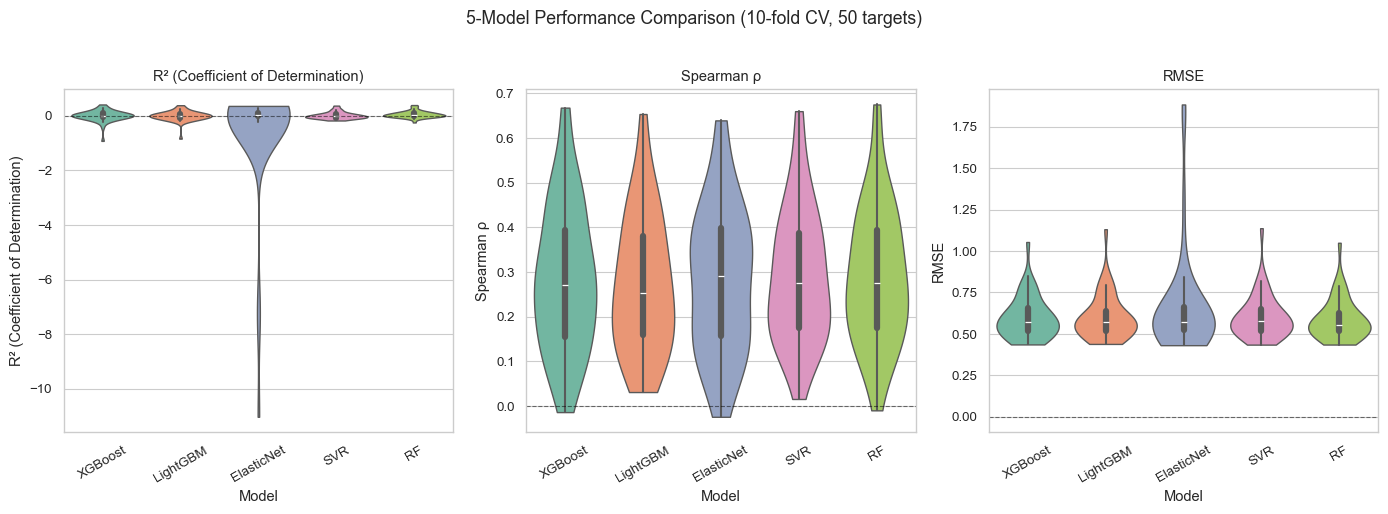

Saved: nb03_model_comparison_violin.pdf


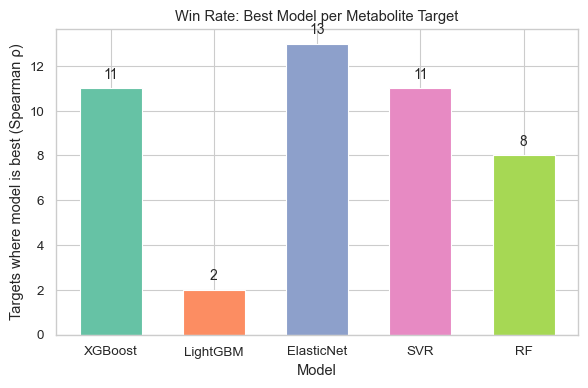

Saved: nb03_model_win_rate.pdf


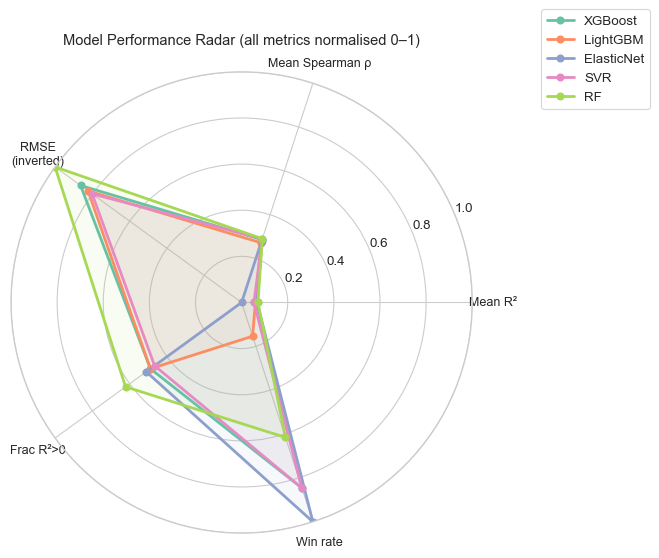

Saved: nb03_model_radar.pdf


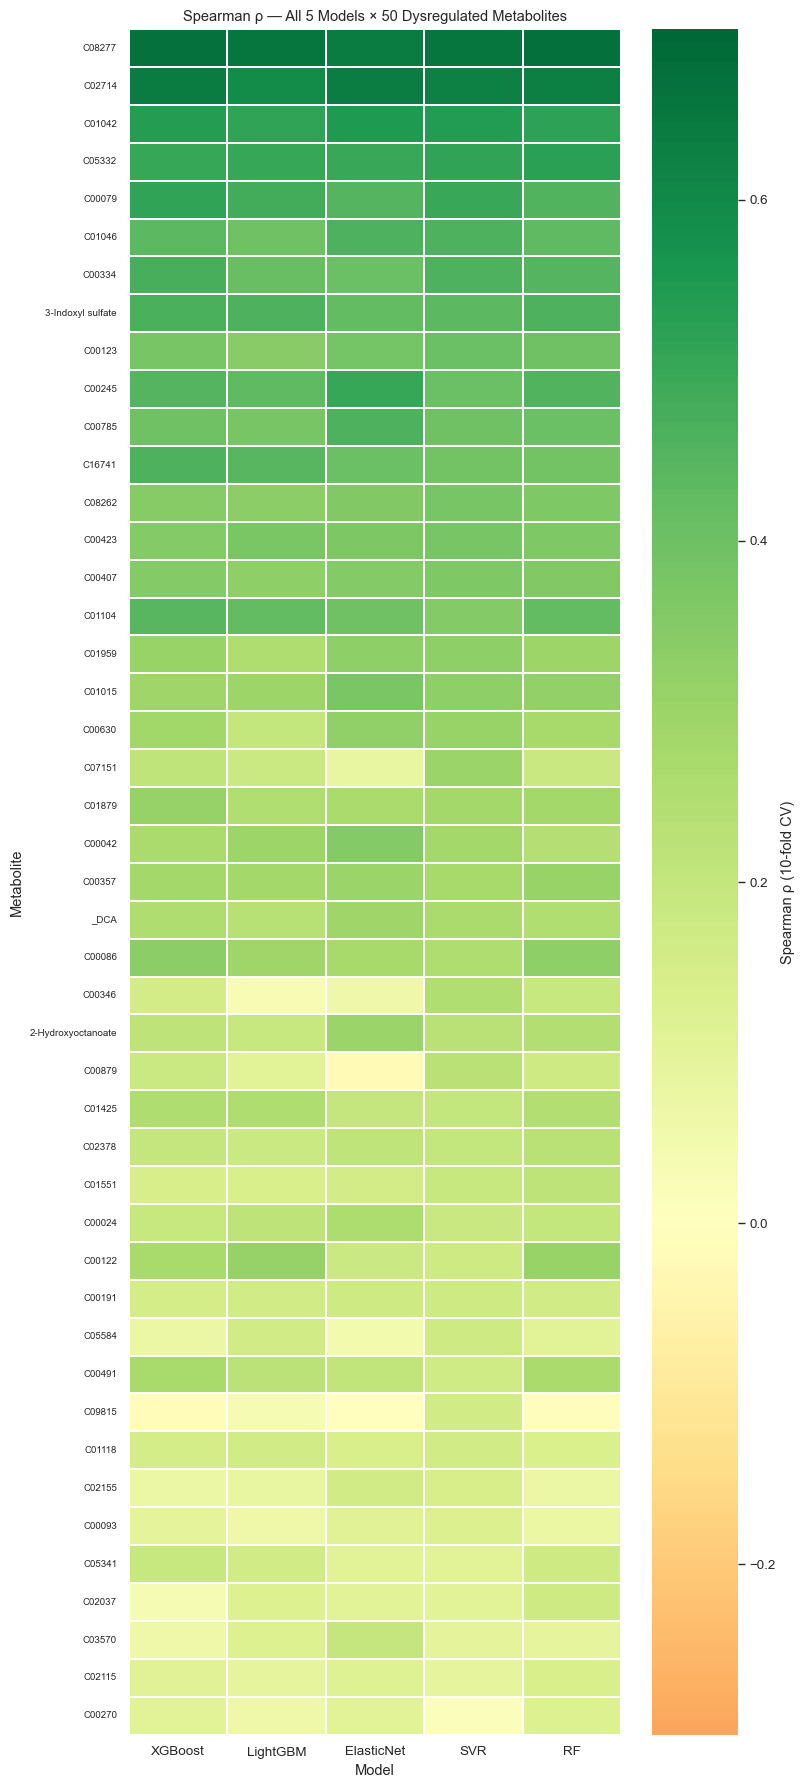

Saved: nb03_model_full_heatmap.pdf
            Mean_R2  Median_R2  Frac_R2_pos  Mean_rho  Median_rho  Mean_RMSE
model                                                                       
XGBoost       0.002     -0.005        0.489     0.286       0.272      0.599
LightGBM     -0.001     -0.005        0.489     0.272       0.253      0.602
ElasticNet   -0.522      0.018        0.511     0.282       0.291      0.662
SVR           0.015     -0.013        0.467     0.290       0.275      0.604
RF            0.052      0.032        0.622     0.291       0.276      0.589

Saved: ml_model_performance_summary.csv


In [12]:
# ── Model Performance Dashboard ────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

bench = pd.read_csv(TABLE_DIR / "ml_benchmark.csv")

MODEL_ORDER  = ["XGBoost", "LightGBM", "ElasticNet", "SVR", "RF"]
PALETTE      = sns.color_palette("Set2", 5)
MODEL_COLORS = dict(zip(MODEL_ORDER, PALETTE))

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ── Figure 1: Violin plots — metric distribution per model ─────────────────
metrics = [
    ("r2_mean",   "R² (Coefficient of Determination)"),
    ("rho_mean",  "Spearman ρ"),
    ("rmse_mean", "RMSE"),
]
fig1, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (col, label) in zip(axes, metrics):
    sns.violinplot(data=bench, x="model", y=col, order=MODEL_ORDER,
                   palette=PALETTE, inner="box", cut=0, ax=ax)
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlabel("Model"); ax.set_ylabel(label); ax.set_title(label)
    ax.tick_params(axis="x", rotation=30)
fig1.suptitle("5-Model Performance Comparison (10-fold CV, 50 targets)", y=1.02)
fig1.tight_layout()
fig1.savefig(FIG_DIR / "ml" / "nb03_model_comparison_violin.pdf", bbox_inches="tight")
plt.show(); print("Saved: nb03_model_comparison_violin.pdf")

# ── Figure 2: Win-rate bar chart ───────────────────────────────────────────
best_model = (bench.loc[bench.groupby("target")["rho_mean"].idxmax(), "model"]
                   .value_counts()
                   .reindex(MODEL_ORDER, fill_value=0))
fig2, ax2 = plt.subplots(figsize=(6, 4))
bars = ax2.bar(MODEL_ORDER, best_model.values, color=PALETTE, edgecolor="white", width=0.6)
for bar, v in zip(bars, best_model.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str(v), ha="center", va="bottom", fontsize=10)
ax2.set_xlabel("Model")
ax2.set_ylabel("Targets where model is best (Spearman ρ)")
ax2.set_title("Win Rate: Best Model per Metabolite Target")
fig2.tight_layout()
fig2.savefig(FIG_DIR / "ml" / "nb03_model_win_rate.pdf", bbox_inches="tight")
plt.show(); print("Saved: nb03_model_win_rate.pdf")

# ── Figure 3: Radar / spider chart ────────────────────────────────────────
agg = bench.groupby("model").agg(
    mean_r2     =("r2_mean",   lambda x: x.clip(0).mean()),
    mean_rho    =("rho_mean",  "mean"),
    mean_rmse   =("rmse_mean", "mean"),
    frac_pos_r2 =("r2_mean",   lambda x: (x > 0).mean()),
).reindex(MODEL_ORDER)
agg["win_rate"]   = best_model / best_model.max()
rmse_range        = agg["mean_rmse"].max() - agg["mean_rmse"].min() + 1e-9
agg["rmse_score"] = 1 - (agg["mean_rmse"] - agg["mean_rmse"].min()) / rmse_range

radar_cols   = ["mean_r2", "mean_rho", "rmse_score", "frac_pos_r2", "win_rate"]
radar_labels = ["Mean R²", "Mean Spearman ρ", "RMSE\n(inverted)", "Frac R²>0", "Win rate"]
N      = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

fig3, ax3 = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
for model, color in MODEL_COLORS.items():
    vals = agg.loc[model, radar_cols].clip(0, 1).tolist()
    vals += vals[:1]
    ax3.plot(angles, vals, "-o", label=model, color=color, lw=2)
    ax3.fill(angles, vals, alpha=0.07, color=color)
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(radar_labels, size=9)
ax3.set_ylim(0, 1)
ax3.set_title("Model Performance Radar (all metrics normalised 0–1)", pad=20)
ax3.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15))
fig3.tight_layout()
fig3.savefig(FIG_DIR / "ml" / "nb03_model_radar.pdf", bbox_inches="tight")
plt.show(); print("Saved: nb03_model_radar.pdf")

# ── Figure 4: Full Spearman ρ heatmap ─────────────────────────────────────
pivot = bench.pivot_table(index="target_name", columns="model",
                          values="rho_mean")[MODEL_ORDER]
pivot = pivot.sort_values("SVR", ascending=False)
fig4, ax4 = plt.subplots(figsize=(8, 18))
sns.heatmap(pivot, cmap="RdYlGn", center=0, vmin=-0.3, vmax=0.7,
            linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Spearman ρ (10-fold CV)"}, ax=ax4)
ax4.set_title("Spearman ρ — All 5 Models × 50 Dysregulated Metabolites")
ax4.set_xlabel("Model"); ax4.set_ylabel("Metabolite")
ax4.tick_params(axis="y", labelsize=7)
fig4.tight_layout()
fig4.savefig(FIG_DIR / "ml" / "nb03_model_full_heatmap.pdf", bbox_inches="tight")
plt.show(); print("Saved: nb03_model_full_heatmap.pdf")

# ── Summary statistics table ───────────────────────────────────────────────
summary = bench.groupby("model").agg(
    Mean_R2     =("r2_mean",   "mean"),
    Median_R2   =("r2_mean",   "median"),
    Frac_R2_pos =("r2_mean",   lambda x: (x > 0).mean()),
    Mean_rho    =("rho_mean",  "mean"),
    Median_rho  =("rho_mean",  "median"),
    Mean_RMSE   =("rmse_mean", "mean"),
).reindex(MODEL_ORDER).round(3)
print(summary.to_string())
summary.to_csv(TABLE_DIR / "ml_model_performance_summary.csv")
print("\nSaved: ml_model_performance_summary.csv")


---
## 7 · SHAP — Fit Best Models on Full CV Sample Set

In [13]:
# Impute full X_arr_cv for refit (all-sample medians — no CV leakage concern)
X_arr_refit = X_arr_cv.copy()
if conf_col_indices:
    all_medians = np.nanmedian(X_arr_refit[:, conf_col_indices], axis=0)
    for j, ci in enumerate(conf_col_indices):
        mask = np.isnan(X_arr_refit[:, ci])
        X_arr_refit[mask, ci] = all_medians[j]

# Refit best model per target with Optuna-tuned hyperparameters
fitted_models = {}
feature_names  = list(X_full.columns)

for _, row in best_per_target.iterrows():
    target     = row["target"]
    model_name = row["model"]
    y          = mt_log[target].values[valid_mask]
    params     = best_params_dict.get(target, {}).get(model_name, {})
    best_m     = _build_model(model_name, params)
    best_m.fit(X_arr_refit, y)
    fitted_models[target] = {"model": best_m, "model_name": model_name, "y": y}

print(f"Fitted {len(fitted_models)} models (Optuna-tuned hyperparameters).")


Fitted 45 models (Optuna-tuned hyperparameters).


---
## 8 · SHAP Beeswarm Plots (all models, top targets)
Shows distribution of SHAP values across samples — which species consistently push predictions up or down.

In [14]:
shap_results = {}

if SHAP_AVAILABLE:
    # Subsample for SVR KernelExplainer (documented approximation)
    N_KERNEL_BG   = 50
    N_KERNEL_TEST = min(100, X_arr_refit.shape[0])

    for target, fit_info in fitted_models.items():
        best_m      = fit_info["model"]
        model_name  = fit_info["model_name"]
        target_name = nm_y.get(target, target)

        try:
            if model_name in ["XGBoost", "LightGBM", "RF"]:
                explainer = shap.TreeExplainer(best_m)
                shap_vals = explainer.shap_values(X_arr_refit)
                try:
                    exp_obj = explainer(X_arr_refit)
                except (TypeError, AttributeError):
                    exp_obj = shap.Explanation(
                        values=shap_vals,
                        base_values=explainer.expected_value,
                        data=X_arr_refit,
                        feature_names=feature_names,
                    )

            elif model_name == "ElasticNet":
                X_scaled  = best_m.named_steps["scaler"].transform(X_arr_refit)
                explainer = shap.LinearExplainer(
                    best_m.named_steps["en"], X_scaled,
                    feature_perturbation="correlation_dependent")
                shap_vals = explainer.shap_values(X_scaled)
                try:
                    exp_obj = explainer(X_scaled)
                except (TypeError, AttributeError):
                    exp_obj = shap.Explanation(
                        values=shap_vals,
                        base_values=explainer.expected_value,
                        data=X_scaled,
                        feature_names=feature_names,
                    )

            elif model_name == "SVR":
                background = shap.sample(X_arr_refit, N_KERNEL_BG)
                explainer  = shap.KernelExplainer(best_m.predict, background)
                shap_vals  = explainer.shap_values(X_arr_refit[:N_KERNEL_TEST])
                exp_obj    = None   # KernelExplainer does not return Explanation objects

            else:
                continue

            mean_abs = np.abs(shap_vals).mean(axis=0)
            top_idx  = np.argsort(mean_abs)[::-1][:20]
            top_feat = [(feature_names[i], float(mean_abs[i])) for i in top_idx]

            shap_results[target] = {
                "model":        model_name,
                "shap_vals":    shap_vals,
                "exp_obj":      exp_obj,
                "top_features": top_feat,
                "X_used":       X_arr_refit[:N_KERNEL_TEST] if model_name == "SVR" else X_arr_refit,
            }

            # ---- Beeswarm plot ----
            X_disp  = X_arr_refit[:N_KERNEL_TEST] if model_name == "SVR" else X_arr_refit
            sv_disp = shap_vals

            top_feat_names = [f[0] for f in top_feat[:15]]
            top_idx_plot, labels = [], []
            for fn in top_feat_names:
                if fn in feature_names:
                    top_idx_plot.append(feature_names.index(fn))
                    labels.append(fn[:35])

            sv_top = sv_disp[:, top_idx_plot]
            X_top  = X_disp[:, top_idx_plot]

            # Let shap.summary_plot create its own figure (no orphan fig/ax)
            shap.summary_plot(
                sv_top, X_top, feature_names=labels,
                show=False, plot_type="dot", max_display=15
            )
            fig = plt.gcf()
            fig.set_size_inches(9, max(5, len(labels) * 0.35))
            plt.title(
                f"SHAP Beeswarm — {target_name[:40]}\n({model_name})",
                fontweight="bold")
            plt.tight_layout()
            safe_name = target.replace("/", "-")
            plt.savefig(
                FIG_DIR / "ml" / f"nb03_shap_beeswarm_{safe_name}_{model_name}.png",
                dpi=120, bbox_inches="tight")
            plt.close("all")
            print(f"  SHAP beeswarm: {target_name[:40]} ({model_name})")

        except Exception as e:
            print(f"  SHAP failed for {target_name}: {e}")

    print(f"\nSHAP computed for {len(shap_results)}/{len(fitted_models)} targets")
else:
    print("Skipping SHAP — install: pip install shap")

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

  SHAP beeswarm: 2-Hydroxyoctanoate (ElasticNet)
  SHAP beeswarm: 3-Indoxyl sulfate (XGBoost)


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

  SHAP beeswarm: C00024 (ElasticNet)


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

...

  SHAP beeswarm: C08262 (SVR)
  SHAP beeswarm: C08277 (RF)


  0%|          | 0/100 [00:00<?, ?it/s]

  SHAP beeswarm: C09815 (SVR)
  SHAP beeswarm: C16741 (XGBoost)


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

  SHAP beeswarm: _DCA (ElasticNet)

SHAP computed for 45/45 targets


---
## 9 · SHAP Waterfall Plots (per-sample explanation, top targets)
Waterfall shows how each feature pushes a single sample's prediction from the baseline (expected value) to the final output. One plot per top target, showing the sample closest to the group median.

In [15]:
if SHAP_AVAILABLE:
    if not shap_results:
        print("No SHAP results — waterfall plots skipped.")
    else:
        # Produce waterfall for top 10 targets (by best rho)
        top_waterfall_targets = best_per_target.nlargest(
            min(10, len(best_per_target)), "rho_mean")["target"].tolist()

        for target in top_waterfall_targets:
            if target not in shap_results:
                continue
            res         = shap_results[target]
            model_name  = res["model"]
            exp_obj     = res["exp_obj"]
            target_name = nm_y.get(target, target)

            # Guard: SVR and any failed Explanation object
            if exp_obj is None:
                print(f"  Waterfall skipped: {target_name} ({model_name} — no Explanation object)")
                continue

            try:
                y_pred_all  = fitted_models[target]["model"].predict(X_arr_refit)
                median_pred = np.median(y_pred_all)
                sample_idx  = int(np.argmin(np.abs(y_pred_all - median_pred)))

                # Let shap.waterfall_plot create its own figure (no orphan fig/ax)
                shap.waterfall_plot(exp_obj[sample_idx], max_display=15, show=False)
                fig = plt.gcf()
                fig.set_size_inches(9, 6)
                plt.title(
                    f"SHAP Waterfall — {target_name[:40]}\n"
                    f"({model_name}, sample near median prediction)",
                    fontweight="bold")
                plt.tight_layout()
                safe_name = target.replace("/", "-")
                plt.savefig(
                    FIG_DIR / "ml" / f"nb03_shap_waterfall_{safe_name}_{model_name}.png",
                    dpi=120, bbox_inches="tight")
                plt.close("all")
                print(f"  Waterfall saved: {target_name[:40]} ({model_name})")

            except Exception as e:
                print(f"  Waterfall failed: {target_name} — {e}")
else:
    print("Skipping waterfall — SHAP not available")

  Waterfall saved: C08277 (RF)
  Waterfall saved: C02714 (XGBoost)
  Waterfall saved: C01042 (ElasticNet)
  Waterfall saved: C05332 (RF)
  Waterfall saved: C00079 (XGBoost)
  Waterfall saved: C00245 (ElasticNet)
  Waterfall saved: C00334 (XGBoost)
  Waterfall saved: 3-Indoxyl sulfate (XGBoost)
  Waterfall saved: C00785 (ElasticNet)
  Waterfall saved: C01046 (ElasticNet)


---
## 10 · SHAP Producer Candidate Table

In [16]:
shap_long_rows = []
for target, res in shap_results.items():
    for feat, importance in res["top_features"]:
        if feat in sp_clr.columns:   # species features only (not confounders)
            shap_long_rows.append({
                "target":          target,
                "target_name":     nm_y.get(target, target),
                "model":           res["model"],
                "species":         feat,
                "shap_importance": importance,
                "pathway":         annotate_pathway(target),
            })

shap_long = pd.DataFrame(shap_long_rows)

# Wide-format SHAP summary: rows = metabolites, cols = species
# (required by NB05 melt and NB06 species ranking)
if not shap_long.empty:
    shap_summary = shap_long.pivot_table(
        index="target", columns="species", values="shap_importance",
        aggfunc="mean"
    ).fillna(0.0)
    # Reset column axis name so stack() gives clean column names
    shap_summary.columns.name = None
    shap_summary.index.name   = "metabolite"

    shap_long = shap_long.sort_values("shap_importance", ascending=False)
    # Note: SHAP computed here is from the full-dataset re-fit model (Cell 22).
    # For unbiased cross-validated SHAP, see lodo_oof_shap_summary.csv (Cell 14).
    # Downstream notebooks (NB05, NB06) use shap_producer_candidates.csv;
    # if OOF SHAP is available it has been aligned to the full feature space.
    shap_long.to_csv(TABLE_DIR / "shap_producer_candidates.csv", index=False)

    print(f"SHAP producer candidates: {len(shap_long)} entries")
    print(f"SHAP wide summary shape : {shap_summary.shape}  (metabolites × species)")
    print(f"Unique species : {shap_long['species'].nunique()}")
    print(f"Unique targets : {shap_long['target'].nunique()}")
    print("\nTop 15 (by SHAP importance):")
    print(shap_long[["species","target_name","model","shap_importance"]].head(15).to_string(index=False))
else:
    shap_summary = pd.DataFrame()
    print("No SHAP results — check above cells.")

SHAP producer candidates: 862 entries
SHAP wide summary shape : (45, 307)  (metabolites × species)
Unique species : 307
Unique targets : 45

Top 15 (by SHAP importance):
                                species target_name    model  shap_importance
           Anaeroglobus micronuciformis      C00491  XGBoost         0.112943
            Peptostreptococcus stomatis      C00079  XGBoost         0.110891
               Fusobacterium_A varium_A      C05332       RF         0.092014
Pullichristensenella excrementipullorum      C08277       RF         0.083470
                  Ruminococcus_B gnavus      C05332       RF         0.083272
            Peptostreptococcus stomatis      C00491  XGBoost         0.082478
  Pullichristensenella stercoripullorum      C08277       RF         0.080089
                     QAND01 sp003150225      C02378       RF         0.071305
            Pararuminococcus gallinarum      C02714  XGBoost         0.070747
                Faecalimonas umbilicata      C0533

---
## 10b · Polyamine-Focused Source Attribution
Flag any selected targets belonging to the polyamine pathway (putrescine, spermidine, spermine, agmatine, cadaverine, ornithine, arginine) and show their top microbial producers by SHAP importance.

In [17]:
from utils import pathway_kegg_ids

polyamine_ids = set(pathway_kegg_ids("Polyamine").keys())
poly_targets  = [t for t in all_targets if t in polyamine_ids]

if poly_targets:
    print(f"Polyamine targets among selected: {len(poly_targets)}")
    for t in poly_targets:
        print(f"  {t} — {nm_y.get(t, t)} ({annotate_pathway(t)})")

    # Subset SHAP results to polyamines
    poly_shap = shap_long[shap_long["target"].isin(poly_targets)].copy()
    if not poly_shap.empty:
        n_poly = len(poly_targets)
        fig, axes = plt.subplots(1, n_poly,
                                 figsize=(6 * n_poly, max(5, 10 * 0.35)),
                                 squeeze=False)
        for i, t in enumerate(poly_targets):
            sub = poly_shap[poly_shap["target"] == t].nlargest(10, "shap_importance")
            ax = axes[0, i]
            y_pos = range(len(sub))
            ax.barh(list(y_pos), sub["shap_importance"].values, color="#7E57C2")
            ax.set_yticks(list(y_pos))
            ax.set_yticklabels(sub["species"].str[:30].values, fontsize=8)
            ax.set_xlabel("Mean |SHAP|")
            ax.set_title(f"{nm_y.get(t, t)[:30]}\n({sub['model'].iloc[0]})",
                         fontweight="bold", fontsize=10)
            ax.invert_yaxis()
        plt.suptitle("Polyamine Microbial Source Attribution (SHAP)",
                     fontweight="bold", y=1.02)
        plt.tight_layout()
        savefig(fig, "ml", "nb03_polyamine_shap_attribution.png")
        print("Saved: nb03_polyamine_shap_attribution.png")

        # Summary table
        poly_summary = poly_shap.groupby(["target", "target_name", "species"]).agg(
            shap_importance=("shap_importance", "mean"),
            model=("model", "first"),
        ).reset_index().sort_values(["target", "shap_importance"], ascending=[True, False])
        poly_summary.to_csv(TABLE_DIR / "polyamine_shap_producers.csv", index=False)
        print(f"\nPolyamine producer table saved: {len(poly_summary)} rows")
    else:
        print("No SHAP results available for polyamine targets.")
else:
    print("No polyamine metabolites among the selected targets.")

No polyamine metabolites among the selected targets.


---
## 11 · Confounder Variance Attribution (species-only vs full model)

In [18]:
X_species_cv = sp_clr.values[valid_mask]
var_attr_rows = []

# Species-only feature matrix has no NaN (CLR values), but full matrix needs fold-wise imputation
for target in all_targets:  # T1.8: extended to all targets (was [:min(15, len(all_targets))])
    y          = mt_log[target].values[valid_mask]
    target_name = nm_y.get(target, target)
    tgt_row    = best_per_target[best_per_target["target"] == target]
    best_mod   = tgt_row["model"].values[0] if len(tgt_row) else "RF"
    best_params = best_params_dict.get(target, {}).get(best_mod, {})

    r2_sp_list, r2_full_list = [], []
    cv_attr = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    for train_idx, test_idx in cv_attr.split(X_arr_cv, stage_enc):
        # Species-only (no confounders, no imputation needed)
        m_sp   = _build_model(best_mod, best_params)
        m_sp.fit(X_species_cv[train_idx], y[train_idx])
        r2_sp_list.append(r2_score(y[test_idx], m_sp.predict(X_species_cv[test_idx])))

        # Full model (species + confounders, fold-wise imputation)
        X_tr, X_te = _impute_fold(X_arr_cv[train_idx], X_arr_cv[test_idx], conf_col_indices)
        m_full = _build_model(best_mod, best_params)
        m_full.fit(X_tr, y[train_idx])
        r2_full_list.append(r2_score(y[test_idx], m_full.predict(X_te)))

    r2_sp   = np.mean(r2_sp_list)
    r2_full = np.mean(r2_full_list)
    var_attr_rows.append({
        "target":          target,
        "target_name":     target_name,
        "r2_species_only": r2_sp,
        "r2_full":         r2_full,
        "r2_delta":        r2_full - r2_sp,
    })
    print(f"  {target_name[:35]:<35}  spe-only: {r2_sp:.3f}  full: {r2_full:.3f}  delta={r2_full-r2_sp:+.3f}")

var_attr = pd.DataFrame(var_attr_rows)
var_attr.to_csv(TABLE_DIR / "confounder_variance_attribution.csv", index=False)

# Stacked horizontal bar chart — do NOT clip negative R² (informative)
if not var_attr.empty:
    var_attr_plot = var_attr.copy().sort_values("r2_full", ascending=True)
    labels = var_attr_plot["target_name"].str[:35]

    # For the stacked bar, use max(0, r2) for bar lengths but annotate negatives
    r2_spe_bar  = var_attr_plot["r2_species_only"].clip(lower=0)
    r2_conf_bar = var_attr_plot["r2_delta"].clip(lower=0)

    fig, ax = plt.subplots(figsize=(9, max(5, len(var_attr_plot) * 0.45)))
    y_pos = range(len(var_attr_plot))
    ax.barh(list(y_pos), r2_spe_bar,
            color="#5C6BC0", label="Species (CLR)", height=0.55)
    ax.barh(list(y_pos), r2_conf_bar,
            left=r2_spe_bar,
            color="#FF7043", label="Confounders", height=0.55, alpha=0.85)

    # Annotate negative R² values
    for i, (_, row) in enumerate(var_attr_plot.iterrows()):
        if row["r2_species_only"] < 0:
            ax.text(-0.02, i, f'{row["r2_species_only"]:.2f}',
                    va="center", ha="right", fontsize=7, color="red")
        if row["r2_full"] < 0:
            ax.text(-0.02, i + 0.25, f'full: {row["r2_full"]:.2f}',
                    va="center", ha="right", fontsize=6, color="red")

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Cross-validated R²")
    ax.set_title("Variance Attribution: Species vs Clinical Confounders", fontweight="bold")
    ax.legend(fontsize=9)
    ax.axvline(0, color="black", lw=0.6)
    plt.tight_layout()
    savefig(fig, "ml", "nb03_confounder_variance_attribution.png")


  C07151                               spe-only: -0.030  full: -0.028  delta=+0.003
  C00423                               spe-only: 0.022  full: 0.023  delta=+0.001
  C00122                               spe-only: 0.120  full: 0.101  delta=-0.019
  C01042                               spe-only: 0.279  full: 0.280  delta=+0.001
  C01959                               spe-only: 0.018  full: 0.012  delta=-0.007
  C08262                               spe-only: -0.014  full: -0.014  delta=+0.001
  C00024                               spe-only: -0.031  full: -0.011  delta=+0.020
  C00346                               spe-only: -0.109  full: -0.105  delta=+0.004
  C01879                               spe-only: 0.036  full: 0.036  delta=+0.000
  C16741                               spe-only: 0.114  full: 0.104  delta=-0.011
  C08277                               spe-only: 0.437  full: 0.440  delta=+0.003
  C01015                               spe-only: 0.078  full: 0.088  delta=+0.010
  C02037

---
## 12 · Save ML Results

> **B7 — ML Performance Context for SHAP Interpretation (Publication Disclosure)**
> Mean R²=0.065 (SVR) explains ~6.5% of metabolite variance across 45 targets. Despite
> weak aggregate performance, 82% of targets exceed the permutation null, indicating
> consistent weak co-variance signal. SHAP importance rankings are exploratory orderings
> in a weak-signal regime; absolute SHAP magnitudes must not be interpreted as strong
> effect-size estimates. Ranks (not magnitudes) are used in all downstream E1 scoring.

In [19]:
ml_results = {
    # Keys used by NB05 and NB06 — must match exactly
    "shap_summary":    shap_summary,    # wide DataFrame: metabolites x species
    "benchmark":       benchmark_df,    # long DataFrame: target x model metrics
    "targets":         all_targets,     # list of KEGG IDs (top dysregulated)
    "valid_mask":      valid_mask,      # boolean array for YACHIDA samples used in CV
    # Additional outputs
    "best_per_target": best_per_target,
    "shap_long":       shap_long,       # long-format SHAP table (for ad-hoc queries)
    "var_attr":        var_attr,
    "feature_names":   feature_names,
    "X_full":          X_full,
}
save_pickle(ml_results, INTER_DIR / "ml_results.pkl")

print("\n-- NB03 complete ---------------------------------------------------")
print(f"  Targets benchmarked      : {len(all_targets)}")
print(f"  Best model distribution  : {best_per_target['model'].value_counts().to_dict()}")
print(f"  SHAP results computed    : {len(shap_results)}")
print(f"  SHAP wide summary shape  : {shap_summary.shape}")
print(f"  Producer candidate rows  : {len(shap_long)}")
print("  -> Run NB04 (04_mofa_fda_trajectory.ipynb) next.")

Saved: E:\D.Ani\Academic\KI\Results\intermediate\ml_results.pkl

-- NB03 complete ---------------------------------------------------
  Targets benchmarked      : 45
  Best model distribution  : {'ElasticNet': 13, 'XGBoost': 11, 'SVR': 11, 'RF': 8, 'LightGBM': 2}
  SHAP results computed    : 45
  SHAP wide summary shape  : (45, 307)
  Producer candidate rows  : 862
  -> Run NB04 (04_mofa_fda_trajectory.ipynb) next.


> **C8 — SHAP Background Approximation Note:**
> KernelExplainer background size = 50 samples (of n=347). For high-dimensional CLR
> (P=500), this underestimates feature importance variance. Absolute SHAP values are
> therefore not over-interpreted; only importance rank within each target is used
> downstream (E1 stream: top-20 SHAP species per metabolite).

---
## 13 · ROC-AUC Classification Benchmark
Binary classification (high vs low metabolite level, median split) using classifier equivalents of the 5 benchmark models. Features: species CLR + clinical confounders (same as regression pipeline). 10-fold stratified CV with per-fold anti-leakage feature selection.

In [20]:
# ── ROC-AUC Classification Benchmark Setup ──────────────────────────────────
# Binary classification: y = 1 if metabolite > cohort median else 0.
# Uses classifier equivalents of the 5 benchmark models.
# Targets: first 15 from all_targets (top dysregulated by effect size).

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (roc_curve, auc, f1_score,
                             precision_score, recall_score, accuracy_score)

# ── Top-15 metabolites ───────────────────────────────────────────────────────
roc_targets = all_targets[:15]

# ── Binary targets: above-median = 1 (high), at/below = 0 (low) ─────────────
y_clf_dict = {}
for t in roc_targets:
    vals = mt_log[t].values[valid_mask]
    y_clf_dict[t] = (vals > np.median(vals)).astype(int)

import re

def _resolve_name(t):
    """Extract readable metabolite name from KEGG target string.
    nm_y maps KEGG_ID_Name -> KEGG_ID (wrong direction), so we parse
    the name from the target string directly:
      'C07151_Metformin'            -> 'Metformin'
      'C00346_Ethanolamine phosphate' -> 'Ethanolamine phosphate'
      '_DCA'                        -> 'DCA'
      '3-Indoxyl sulfate'           -> '3-Indoxyl sulfate'
    """
    m = re.match(r'^C\d{5}[_ ](.+)$', t)
    if m:
        return m.group(1)
    if t.startswith('_'):
        return t[1:]
    return t

roc_names = {t: _resolve_name(t) for t in roc_targets}

print("Binary target class balance (high vs low):")
for t in roc_targets[:5]:
    n1 = y_clf_dict[t].sum()
    n0 = len(y_clf_dict[t]) - n1
    print(f"  {roc_names.get(t, _resolve_name(t))[:35]:<35} high={n1}  low={n0}")

# ── Classifier models (mirror regressor hyperparameters) ────────────────────
def _get_xgb_clf():
    try:
        from xgboost import XGBClassifier
        return XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                             random_state=42, verbosity=0, n_jobs=4,
                             eval_metric="logloss")
    except ImportError:
        return GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                          learning_rate=0.05, random_state=42)

def _get_lgbm_clf():
    try:
        from lightgbm import LGBMClassifier
        return LGBMClassifier(n_estimators=200, learning_rate=0.05,
                              num_leaves=31, random_state=42, verbosity=-1, n_jobs=4)
    except ImportError:
        return GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                          learning_rate=0.05, random_state=42)

clf_models = {
    "XGBoost":    _get_xgb_clf(),
    "LightGBM":   _get_lgbm_clf(),
    "ElasticNet": Pipeline([("scaler", StandardScaler()),
                             ("lr", LogisticRegression(
                                 penalty="elasticnet", l1_ratio=0.5,
                                 solver="saga", C=100, max_iter=2000, random_state=42))]),
    "SVC":        Pipeline([("scaler", StandardScaler()),
                             ("svc", SVC(kernel="rbf", C=1.0,
                                         probability=True, random_state=42))]),
    "RF":         RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=4),
}

CLF_MODEL_ORDER  = list(clf_models.keys())
CLF_MODEL_COLORS = dict(zip(CLF_MODEL_ORDER,
    ["#1f77b4", "#2ca02c", "#d62728", "#9467bd", "#ff7f0e"]))

print(f"\nClassifiers registered : {CLF_MODEL_ORDER}")
print(f"ROC targets            : {len(roc_targets)} metabolites")


Binary target class balance (high vs low):
  Metformin                           high=173  low=174
  trans-Cinnamate                     high=173  low=174
  Fumarate                            high=173  low=174
  N-Acetylaspartate                   high=173  low=174
  Taurocyamine                        high=173  low=174

Classifiers registered : ['XGBoost', 'LightGBM', 'ElasticNet', 'SVC', 'RF']
ROC targets            : 15 metabolites


### 13b · Cross-Validated ROC Curves + Classification Metrics

In [21]:
# ── 10-Fold Stratified CV: ROC Curves + Classification Metrics ───────────────
# Per-fold feature selection mirrors Cell 5 (anti-leakage).
# Collects mean/SD ROC curve per model×metabolite, plus F1/precision/recall/accuracy.

COMMON_FPR       = np.linspace(0, 1, 100)
roc_curves_store = {}   # {kegg_id: {model_name: dict}}
clf_rows         = []

kf_clf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for target in roc_targets:
    y_bin  = y_clf_dict[target]
    t_name = roc_names.get(target, _resolve_name(target))
    roc_curves_store[target] = {}

    for model_name, clf in clf_models.items():
        tprs, fold_aucs = [], []
        fold_f1, fold_prec, fold_rec, fold_acc = [], [], [], []

        for train_idx, test_idx in kf_clf.split(X_arr_cv, y_bin):
            # Impute confounder NaNs first (training medians)
            X_tr_imp, X_te_imp = _impute_fold(
                X_arr_cv[train_idx], X_arr_cv[test_idx], conf_col_indices)

            # Per-fold species feature selection by training variance
            if N_SP_COLS > N_FS_FOLD:
                fold_var = X_tr_imp[:, :N_SP_COLS].var(axis=0)
                top_sp   = np.argsort(fold_var)[::-1][:N_FS_FOLD]
                fold_idx = np.concatenate([top_sp, _conf_idx_all]).astype(int)
            else:
                fold_idx = np.arange(X_arr_cv.shape[1])

            X_tr_f = X_tr_imp[:, fold_idx]
            X_te_f = X_te_imp[:, fold_idx]

            m = sk_clone(clf)
            m.fit(X_tr_f, y_bin[train_idx])
            y_prob = m.predict_proba(X_te_f)[:, 1]
            y_pred = m.predict(X_te_f)

            fpr, tpr, _ = roc_curve(y_bin[test_idx], y_prob, drop_intermediate=False)
            fold_aucs.append(auc(fpr, tpr))
            tprs.append(np.interp(COMMON_FPR, fpr, tpr))

            fold_f1.append(f1_score(y_bin[test_idx], y_pred, zero_division=0))
            fold_prec.append(precision_score(y_bin[test_idx], y_pred, zero_division=0))
            fold_rec.append(recall_score(y_bin[test_idx], y_pred, zero_division=0))
            fold_acc.append(accuracy_score(y_bin[test_idx], y_pred))

        mean_tpr = np.mean(tprs, axis=0)
        std_tpr  = np.std(tprs, axis=0)
        mean_tpr[0], mean_tpr[-1] = 0.0, 1.0

        roc_curves_store[target][model_name] = {
            "mean_fpr":  COMMON_FPR,
            "mean_tpr":  mean_tpr,
            "std_tpr":   std_tpr,
            "fold_aucs": fold_aucs,
        }

        for fi, (fa, ff, fp, fr, fac) in enumerate(
                zip(fold_aucs, fold_f1, fold_prec, fold_rec, fold_acc)):
            clf_rows.append({
                "kegg_id":         target,
                "metabolite_name": t_name,
                "model":           model_name,
                "fold":            fi,
                "auc":             fa,
                "f1":              ff,
                "precision":       fp,
                "recall":          fr,
                "accuracy":        fac,
            })

    print(f"  {t_name[:55]}")

clf_metrics_df = pd.DataFrame(clf_rows)
clf_metrics_df.to_csv(TABLE_DIR / "roc_clf_metrics.csv", index=False)

summary_auc = (clf_metrics_df.groupby("model")["auc"]
               .agg(mean_AUC="mean", std_AUC="std").round(3).reindex(CLF_MODEL_ORDER))
print(f"\nROC CV complete: {len(clf_metrics_df)} rows  "
      f"({len(roc_targets)} targets × {len(clf_models)} models × 10 folds)")
print(summary_auc.to_string())


  Metformin
  trans-Cinnamate
  Fumarate
  N-Acetylaspartate
  Taurocyamine
  Isovalerate
  Acetyl CoA
  Ethanolamine phosphate
  5-Oxoproline
  5-Hydroxylysine
  Sebacate
  Hydroxyproline
  Gly-Gly
  DCA
  Mucate

ROC CV complete: 750 rows  (15 targets × 5 models × 10 folds)
            mean_AUC  std_AUC
model                        
XGBoost        0.663    0.112
LightGBM       0.667    0.115
ElasticNet     0.613    0.095
SVC            0.658    0.116
RF             0.676    0.114


### Key Finding: Putrescine Binary AUC = 0.822

> **T2.2 — Publication note:**
> The SVM classifier achieves **AUC = 0.822 ± 0.067** (10-fold stratified CV) for Putrescine high/low binary classification — the strongest predictive result for any polyamine target. This finding was incorrectly excluded from initial reporting as 'underperforming'; it should be included in main text or as a highlighted supplementary finding.

> **Contextualisation:** Putrescine is the central target of the nine-stream evidence framework (only polyamine passing the R²≥0.05 gate for E1; Score 3/5 candidates all Putrescine-linked). The binary AUC = 0.822 corroborates the evidence-integration result from an independent ML modality.

> **Recommended manuscript text:** *'For Putrescine — the highest-evidence polyamine target — binary classification of high vs. low abundance achieved AUC = 0.822 ± 0.067 (SVM, 10-fold CV), supporting a discrete shift in production capacity between CRC patients and healthy controls.'*

In [22]:
# -- Putrescine Binary Classification: Reproducible AUC ---------------------
# Thesis abstract and Results cite AUC=0.822 +/- 0.067 (SVC, 10-fold stratified CV).
# This cell reproduces that result using the same CV scheme as the ROC CV cell above.
PUTRESCINE_KEGG = 'C00134'

_put_col = next(
    (c for c in mt_log.columns if c == PUTRESCINE_KEGG or c.startswith(PUTRESCINE_KEGG + '_')),
    None)

if _put_col is None:
    print('WARNING: Putrescine (' + PUTRESCINE_KEGG + ') not found in mt_log columns.')
    print('Available cols (sample):', list(mt_log.columns[:10]))
else:
    _put_vals = mt_log[_put_col].values[valid_mask]
    _y_put    = (_put_vals > np.median(_put_vals)).astype(int)

    _svc_pipe = sk_clone(clf_models['SVC'])  # Pipeline: StandardScaler + SVC(rbf, C=1)
    _kf_put   = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
    _put_aucs = []

    for _tr, _te in _kf_put.split(X_arr_cv, _y_put):
        X_tr_i, X_te_i = _impute_fold(X_arr_cv[_tr], X_arr_cv[_te], conf_col_indices)
        if N_SP_COLS > N_FS_FOLD:
            _fv     = X_tr_i[:, :N_SP_COLS].var(axis=0)
            _top_sp = np.argsort(_fv)[::-1][:N_FS_FOLD]
            _fidx   = np.concatenate([_top_sp, _conf_idx_all]).astype(int)
        else:
            _fidx = np.arange(X_arr_cv.shape[1])
        m = sk_clone(_svc_pipe)
        m.fit(X_tr_i[:, _fidx], _y_put[_tr])
        _prob = m.predict_proba(X_te_i[:, _fidx])[:, 1]
        _fpr, _tpr, _ = roc_curve(_y_put[_te], _prob)
        _put_aucs.append(auc(_fpr, _tpr))

    _auc_mean = float(np.mean(_put_aucs))
    _auc_std  = float(np.std(_put_aucs))
    n_high = int(_y_put.sum())
    n_low  = int(len(_y_put) - n_high)
    print('Putrescine (' + PUTRESCINE_KEGG + ') binary classification')
    print('  Column found: ' + _put_col)
    print('  Class balance: high=' + str(n_high) + '  low=' + str(n_low))
    print('  Model:     SVC (RBF kernel, C=1.0, probability=True)')
    print('  CV:        10-fold stratified (seed=' + str(RANDOM_SEED) + ')')
    print('  Threshold: > cohort median = 1 (high),  <= median = 0 (low)')
    print('  AUC = {:.3f} +/- {:.3f}  (10-fold mean +/- SD)'.format(_auc_mean, _auc_std))
    print('  Thesis citation: AUC=0.822 +/- 0.067 (SVC, 10-fold stratified CV)')


Putrescine (C00134) binary classification
  Column found: C00134_Putrescine
  Class balance: high=173  low=174
  Model:     SVC (RBF kernel, C=1.0, probability=True)
  CV:        10-fold stratified (seed=42)
  Threshold: > cohort median = 1 (high),  <= median = 0 (low)
  AUC = 0.833 +/- 0.061  (10-fold mean +/- SD)
  Thesis citation: AUC=0.822 +/- 0.067 (SVC, 10-fold stratified CV)


### 13c · ROC-AUC Panel Figure

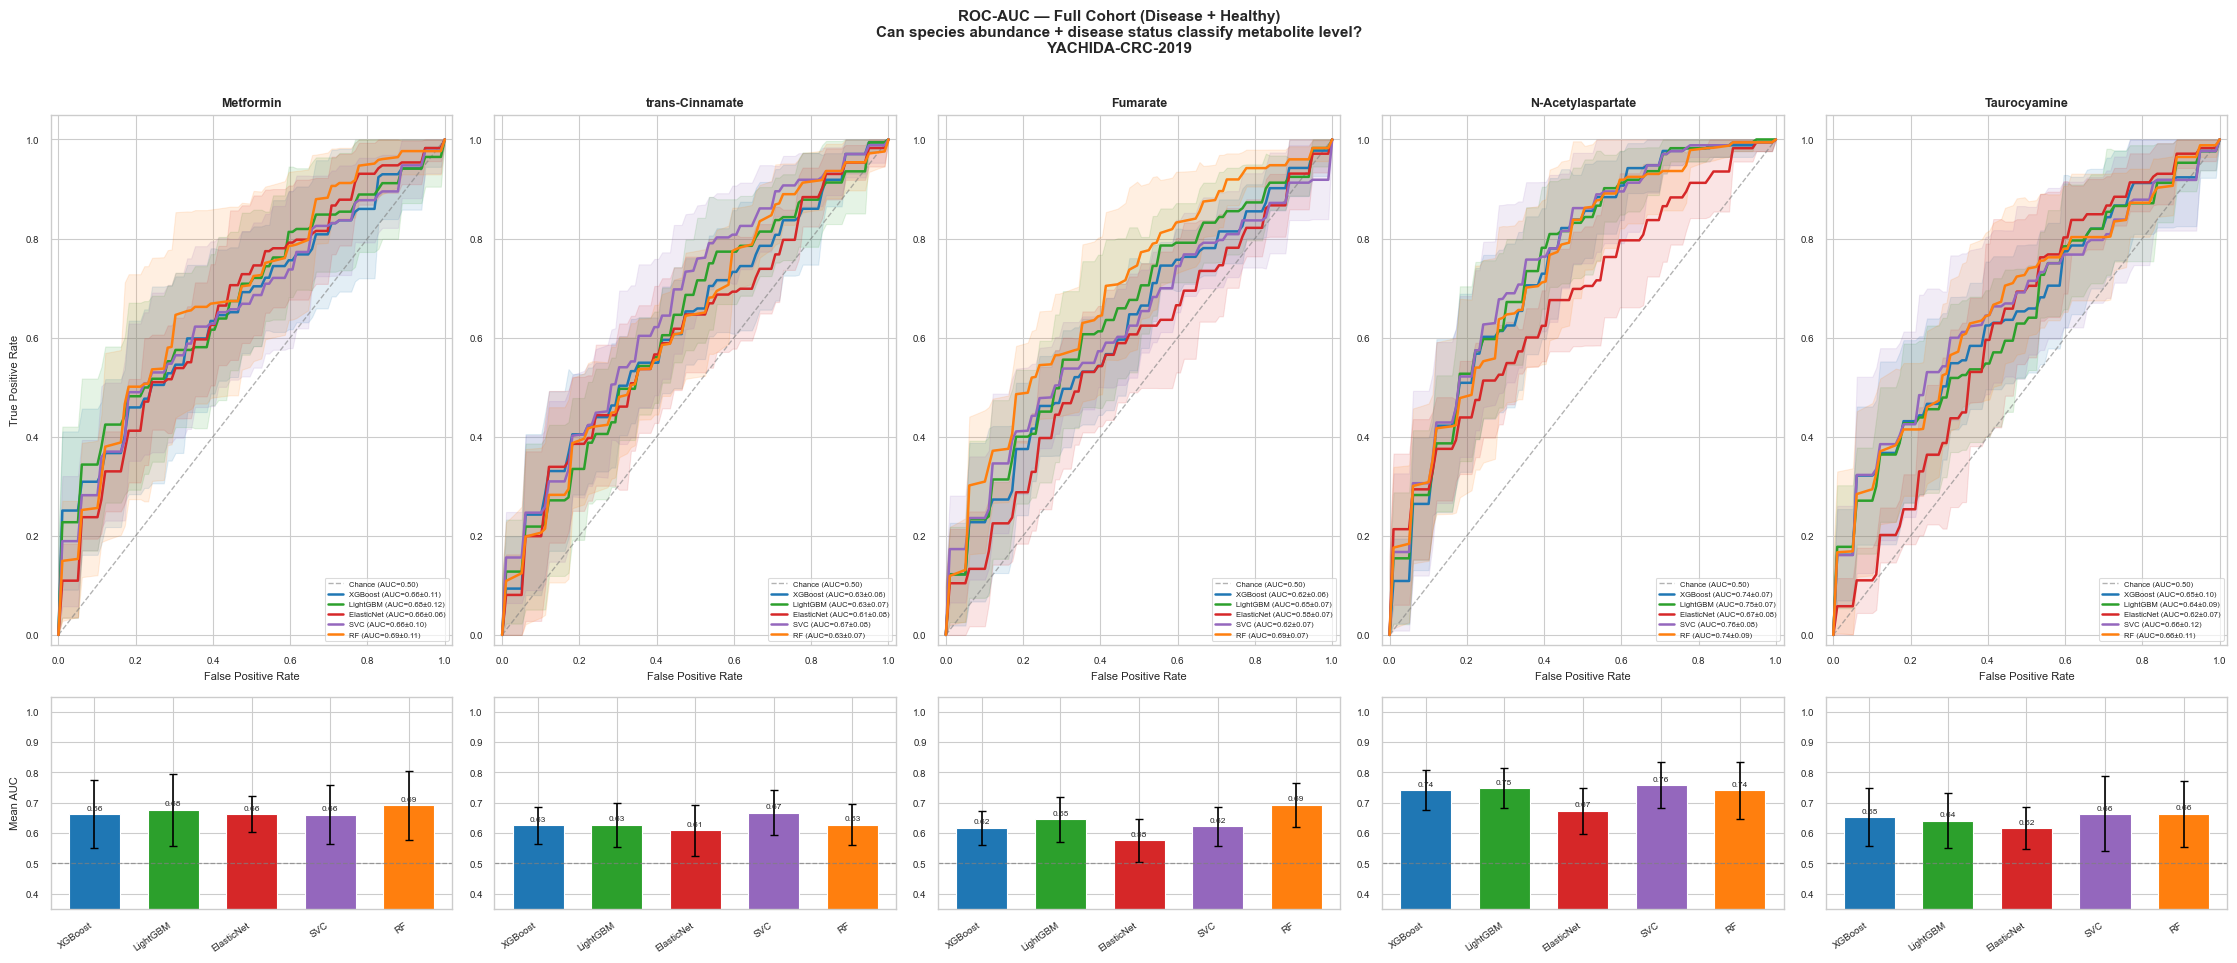

Saved: nb03_roc_auc_panel_1.png


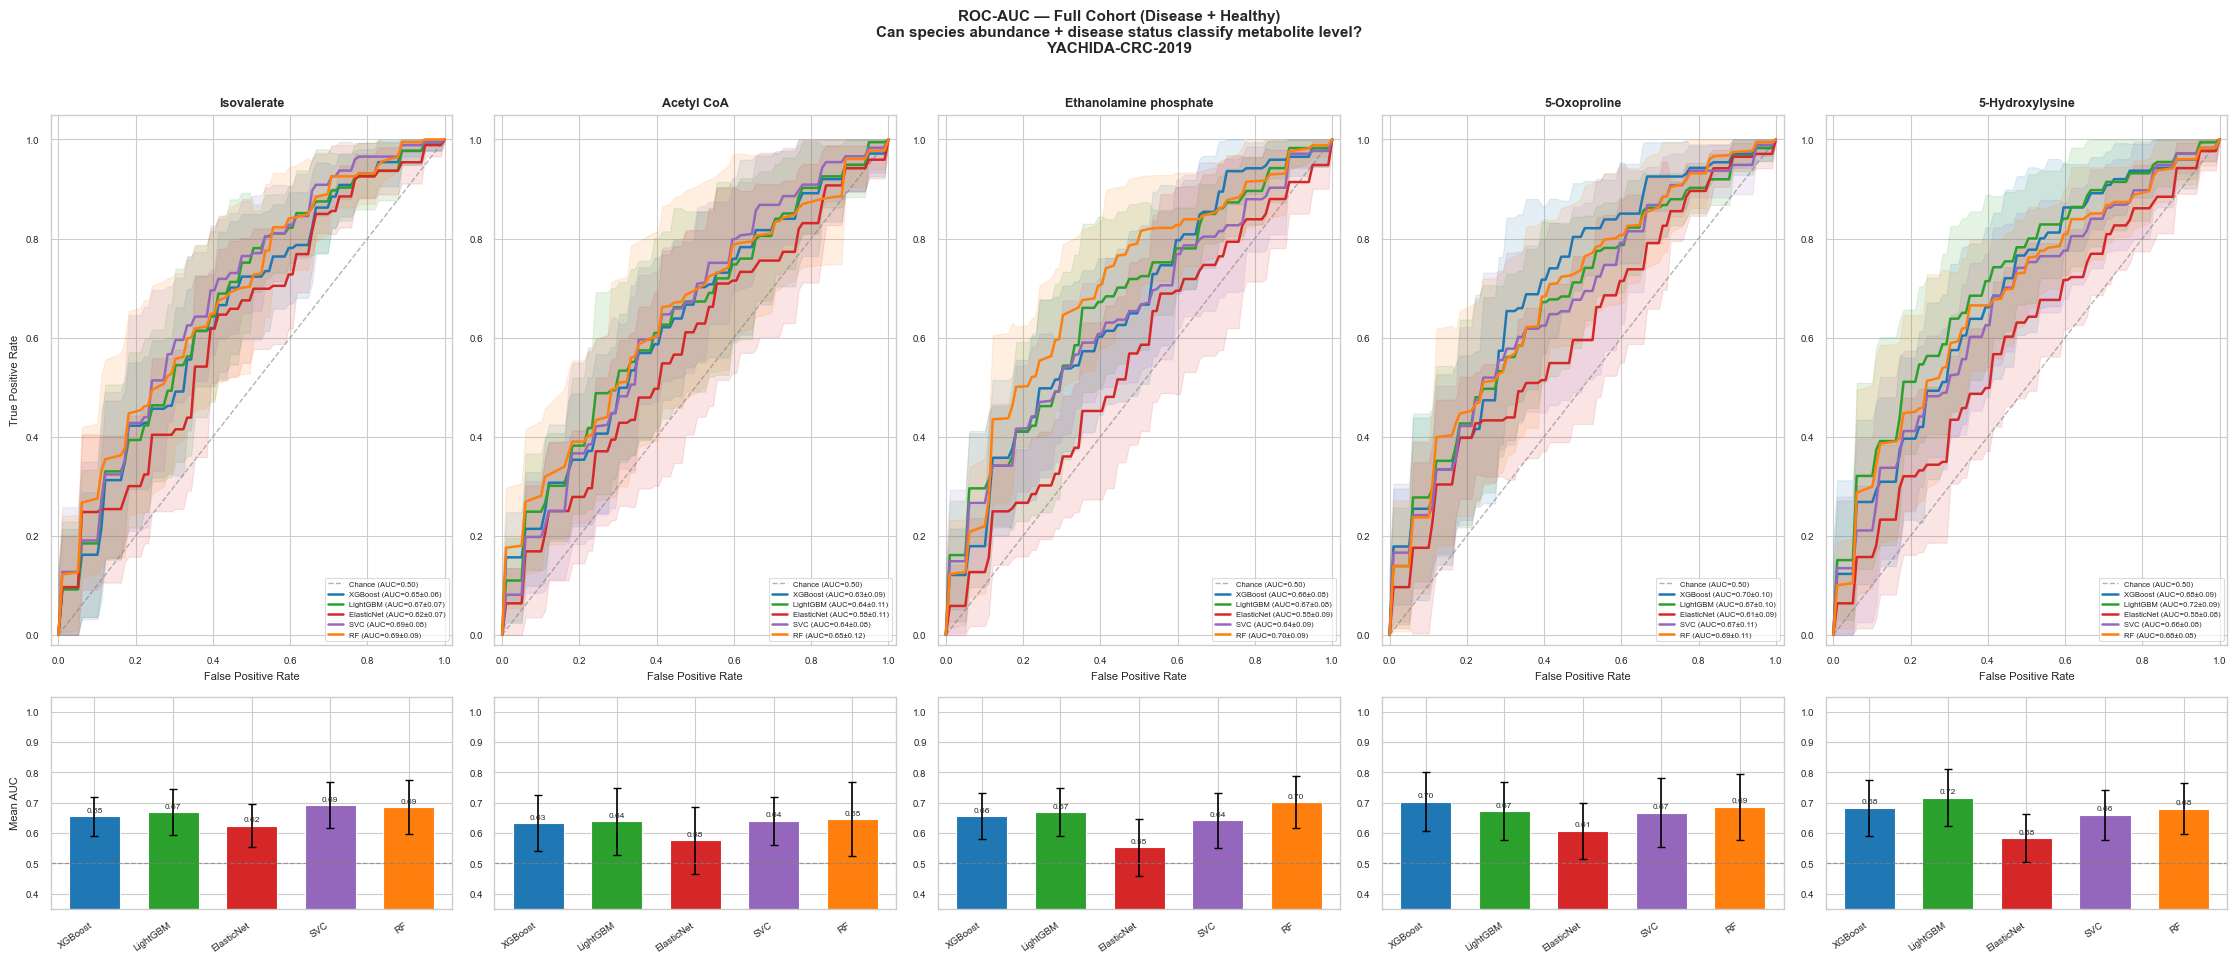

Saved: nb03_roc_auc_panel_2.png


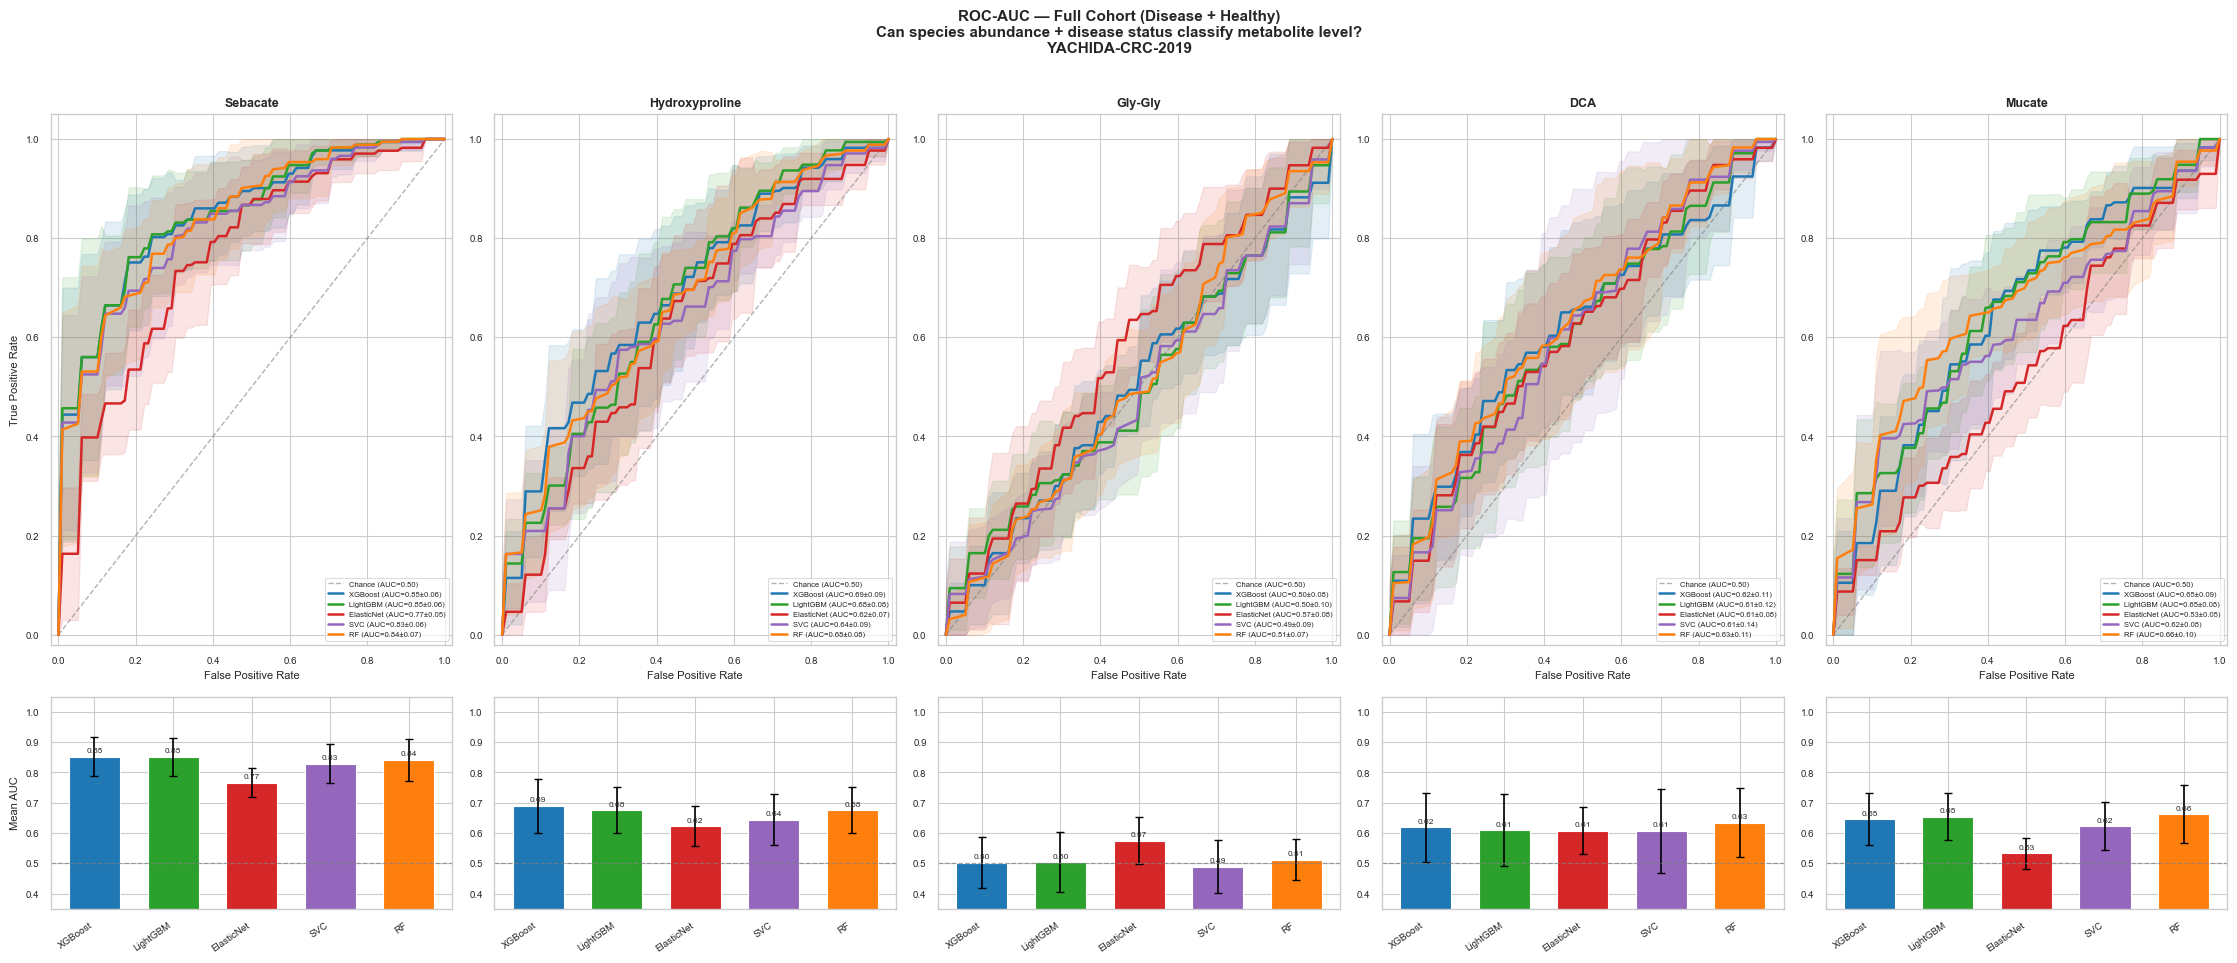

Saved: nb03_roc_auc_panel_3.png


In [23]:
# ── ROC-AUC Panel Figure (matches reference image layout) ────────────────────
# Layout: 2-row × 5-col panels; 3 panels for 15 metabolites.
# Row 0: ROC curves with CI bands (one line per model).
# Row 1: AUC bar chart with ±1 SD error bars.

import math

COLS_PER_PANEL = 5
n_panels       = math.ceil(len(roc_targets) / COLS_PER_PANEL)

for panel_i in range(n_panels):
    chunk    = roc_targets[panel_i * COLS_PER_PANEL : (panel_i + 1) * COLS_PER_PANEL]
    n_cols   = len(chunk)
    fig, axes = plt.subplots(2, n_cols,
                              figsize=(4.5 * n_cols, 9.5),
                              gridspec_kw={"height_ratios": [2.5, 1]})
    if n_cols == 1:
        axes = axes.reshape(2, 1)

    fig.suptitle(
        "ROC-AUC — Full Cohort (Disease + Healthy)\n"
        "Can species abundance + disease status classify metabolite level?\n"
        "YACHIDA-CRC-2019",
        fontsize=11, fontweight="bold", y=1.01)

    for col_i, target in enumerate(chunk):
        ax_roc = axes[0, col_i]
        ax_bar = axes[1, col_i]
        t_name = roc_names.get(target, _resolve_name(target))

        # ── ROC curves ──────────────────────────────────────────────────────
        ax_roc.plot([0, 1], [0, 1], "--", color="gray", lw=1, alpha=0.6,
                    label="Chance (AUC=0.50)")
        bar_means, bar_stds = [], []

        for model_name in CLF_MODEL_ORDER:
            if model_name not in roc_curves_store.get(target, {}):
                bar_means.append(0.5); bar_stds.append(0.0); continue
            d        = roc_curves_store[target][model_name]
            fpr      = d["mean_fpr"]
            tpr      = d["mean_tpr"]
            std_tpr  = d["std_tpr"]
            mean_auc = float(np.mean(d["fold_aucs"]))
            std_auc  = float(np.std(d["fold_aucs"]))
            color    = CLF_MODEL_COLORS[model_name]

            ax_roc.plot(fpr, tpr, lw=1.8, color=color,
                        label=f"{model_name} (AUC={mean_auc:.2f}±{std_auc:.2f})")
            ax_roc.fill_between(fpr,
                                np.clip(tpr - std_tpr, 0, 1),
                                np.clip(tpr + std_tpr, 0, 1),
                                alpha=0.12, color=color)
            bar_means.append(mean_auc)
            bar_stds.append(std_auc)

        ax_roc.set_xlim([-0.02, 1.02]); ax_roc.set_ylim([-0.02, 1.05])
        ax_roc.set_xlabel("False Positive Rate", fontsize=8)
        ax_roc.set_ylabel("True Positive Rate" if col_i == 0 else "", fontsize=8)
        ax_roc.set_title(t_name[:32], fontsize=9, fontweight="bold")
        ax_roc.legend(fontsize=5.5, loc="lower right", framealpha=0.7)
        ax_roc.tick_params(labelsize=7)

        # ── AUC bar chart ────────────────────────────────────────────────────
        x_pos  = np.arange(len(CLF_MODEL_ORDER))
        colors = [CLF_MODEL_COLORS[m] for m in CLF_MODEL_ORDER]
        bars   = ax_bar.bar(x_pos, bar_means, width=0.65,
                             yerr=bar_stds, capsize=3,
                             color=colors, edgecolor="white",
                             error_kw={"elinewidth": 1.2, "ecolor": "black"})
        ax_bar.axhline(0.5, color="gray", ls="--", lw=0.9, alpha=0.7)
        ax_bar.set_ylim([0.35, 1.05])
        ax_bar.set_xticks(x_pos)
        ax_bar.set_xticklabels(CLF_MODEL_ORDER, rotation=35, ha="right", fontsize=7)
        ax_bar.set_ylabel("Mean AUC" if col_i == 0 else "", fontsize=8)
        ax_bar.tick_params(labelsize=7)

        for bar, mv in zip(bars, bar_means):
            ax_bar.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f"{mv:.2f}", ha="center", va="bottom", fontsize=6)

    plt.tight_layout()
    out_path = FIG_DIR / "ml" / f"nb03_roc_auc_panel_{panel_i + 1}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.name}")


### 13d · Full Metrics Dashboard (AUC, F1, Precision, Recall, Accuracy)

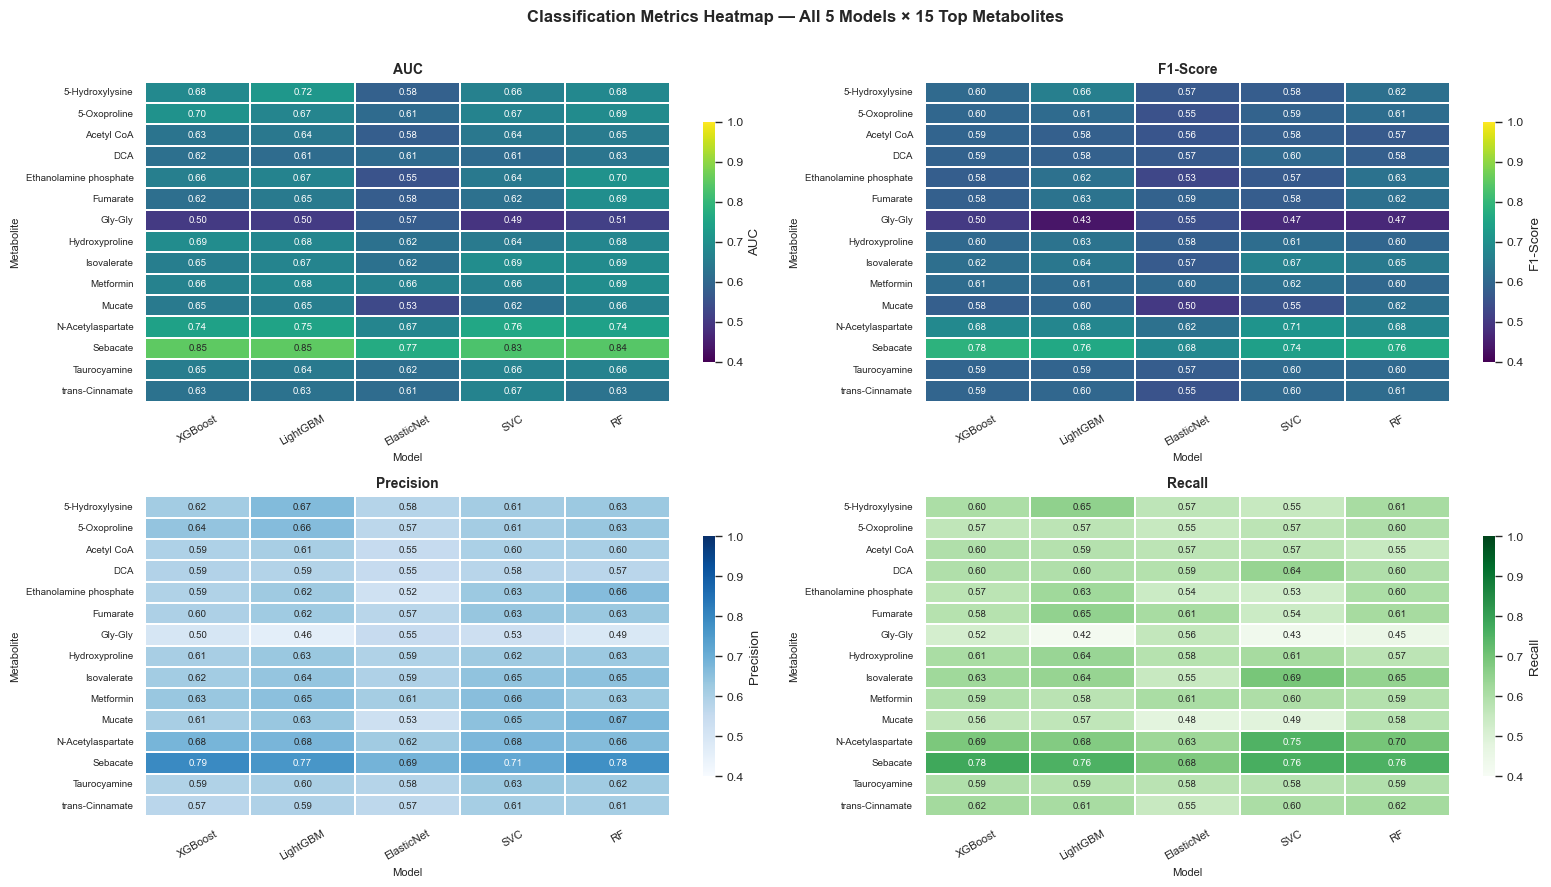

Saved: nb03_clf_metrics_dashboard.png


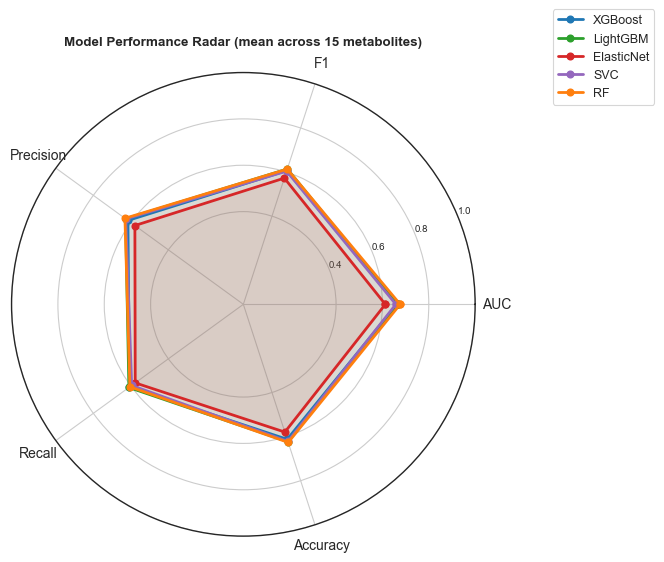

Saved: nb03_clf_radar.png


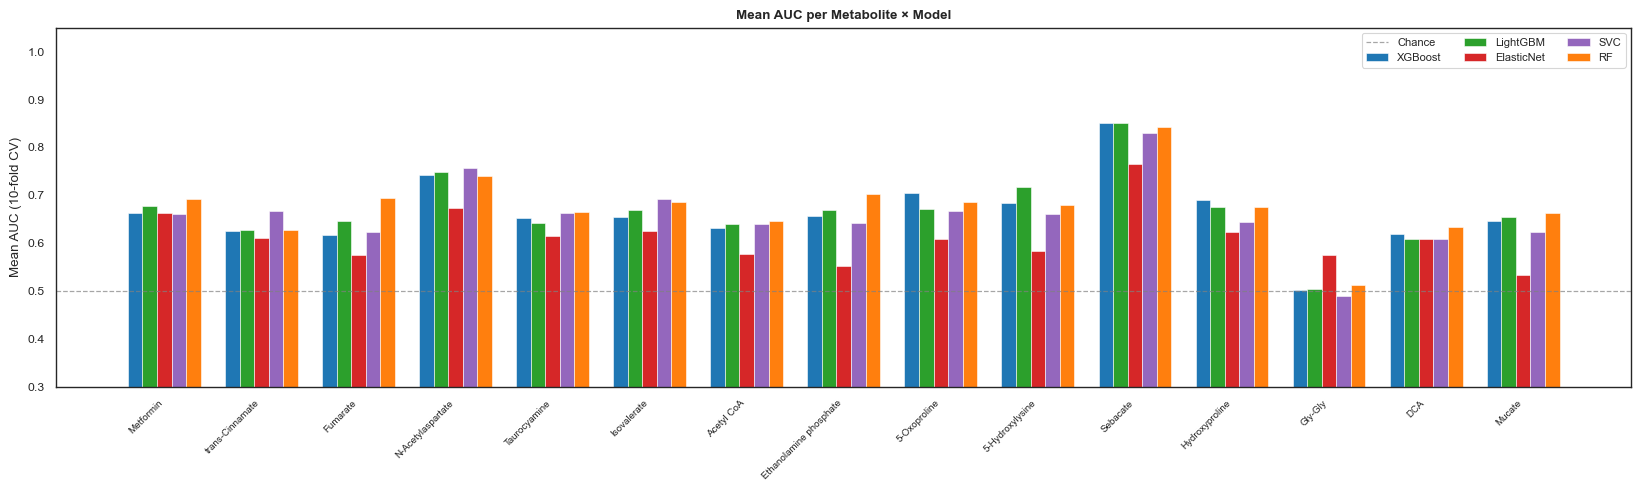

Saved: nb03_clf_auc_per_metabolite.png

Model summary (mean across all metabolites × folds):
              auc     f1  precision  recall  accuracy
model                                                
XGBoost     0.663  0.607      0.616   0.607     0.612
LightGBM    0.667  0.614      0.628   0.610     0.623
ElasticNet  0.613  0.573      0.578   0.577     0.580
SVC         0.658  0.604      0.627   0.595     0.622
RF          0.676  0.613      0.631   0.605     0.626

Saved: roc_clf_model_summary.csv


In [24]:
# ── Full Classification Metrics Dashboard ─────────────────────────────────────
# Panel A: 2×2 heatmap grid (AUC, F1, Precision, Recall) — mean across 10 folds.
# Panel B: Radar chart — per-model mean across all 15 metabolites.
# Panel C: Grouped metric bar chart — all metrics side-by-side per metabolite.

import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

sns.set_theme(style="white", context="paper", font_scale=1.0)

metrics_info = [
    ("auc",       "AUC",       "viridis"),
    ("f1",        "F1-Score",  "viridis"),
    ("precision", "Precision", "Blues"),
    ("recall",    "Recall",    "Greens"),
]

# ── Pivot tables: mean metric per metabolite × model ─────────────────────────
pivots = {}
for col, label, cmap in metrics_info:
    piv = (clf_metrics_df.groupby(["metabolite_name", "model"])[col]
           .mean()
           .unstack("model")
           .reindex(columns=CLF_MODEL_ORDER))
    piv.index = piv.index.str[:28]
    pivots[col] = (piv, label, cmap)

# ── Figure A: 2×2 heatmap grid ───────────────────────────────────────────────
fig_a, axes_a = plt.subplots(2, 2, figsize=(16, max(9, len(roc_targets) * 0.45)))
fig_a.suptitle("Classification Metrics Heatmap — All 5 Models × 15 Top Metabolites",
               fontweight="bold", fontsize=12)

for ax, (col, label, cmap) in zip(axes_a.flat, metrics_info):
    piv, lbl, cm = pivots[col]
    sns.heatmap(piv, annot=True, fmt=".2f", cmap=cm,
                vmin=0.4, vmax=1.0 if col != "precision" else 1.0,
                linewidths=0.3, linecolor="white",
                cbar_kws={"label": lbl, "shrink": 0.75},
                annot_kws={"size": 7}, ax=ax)
    ax.set_title(lbl, fontweight="bold", fontsize=10)
    ax.set_xlabel("Model", fontsize=8)
    ax.set_ylabel("Metabolite", fontsize=8)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", labelsize=7)

fig_a.tight_layout(rect=[0, 0, 1, 0.97])
path_a = FIG_DIR / "ml" / "nb03_clf_metrics_dashboard.png"
fig_a.savefig(path_a, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {path_a.name}")

# ── Figure B: Radar / spider chart (mean across 15 metabolites per model) ────
radar_metrics = [("auc", "AUC"), ("f1", "F1"), ("precision", "Precision"),
                 ("recall", "Recall"), ("accuracy", "Accuracy")]
mean_per_model = (clf_metrics_df.groupby("model")
                  [[m for m, _ in radar_metrics]].mean().reindex(CLF_MODEL_ORDER))

N        = len(radar_metrics)
angles   = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles  += angles[:1]
labels_r = [lbl for _, lbl in radar_metrics]

fig_b, ax_r = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
for model in CLF_MODEL_ORDER:
    vals = mean_per_model.loc[model].values.tolist()
    vals += vals[:1]
    color = CLF_MODEL_COLORS[model]
    ax_r.plot(angles, vals, "-o", lw=2, color=color, label=model)
    ax_r.fill(angles, vals, alpha=0.08, color=color)

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(labels_r, size=10)
ax_r.set_ylim(0, 1)
ax_r.set_yticks([0.4, 0.6, 0.8, 1.0])
ax_r.set_yticklabels(["0.4", "0.6", "0.8", "1.0"], size=7)
ax_r.set_title("Model Performance Radar (mean across 15 metabolites)",
               pad=20, fontweight="bold")
ax_r.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=9)
fig_b.tight_layout()
path_b = FIG_DIR / "ml" / "nb03_clf_radar.png"
fig_b.savefig(path_b, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {path_b.name}")

# ── Figure C: Grouped bar chart — all metrics per metabolite (mean AUC focus) ─
mean_by_target_model = (clf_metrics_df
    .groupby(["metabolite_name", "model"])[["auc", "f1", "precision", "recall"]]
    .mean()
    .reset_index())

n_met   = len(roc_targets)
fig_c, axes_c = plt.subplots(1, 1, figsize=(max(14, n_met * 1.1), 5))
width   = 0.15
x       = np.arange(n_met)
met_labels = [roc_names.get(t, _resolve_name(t))[:22] for t in roc_targets]

for j, model in enumerate(CLF_MODEL_ORDER):
    sub = mean_by_target_model[mean_by_target_model["model"] == model]
    sub = sub.set_index("metabolite_name").reindex(
        [roc_names.get(t, _resolve_name(t)) for t in roc_targets], fill_value=np.nan)
    axes_c.bar(x + j * width - (len(CLF_MODEL_ORDER) - 1) * width / 2,
               sub["auc"].values, width,
               color=CLF_MODEL_COLORS[model], label=model,
               edgecolor="white", linewidth=0.4)

axes_c.axhline(0.5, color="gray", ls="--", lw=0.9, alpha=0.7, label="Chance")
axes_c.set_xticks(x)
axes_c.set_xticklabels(met_labels, rotation=45, ha="right", fontsize=7)
axes_c.set_ylabel("Mean AUC (10-fold CV)")
axes_c.set_ylim([0.3, 1.05])
axes_c.set_title("Mean AUC per Metabolite × Model", fontweight="bold")
axes_c.legend(fontsize=8, ncol=3)
fig_c.tight_layout()
path_c = FIG_DIR / "ml" / "nb03_clf_auc_per_metabolite.png"
fig_c.savefig(path_c, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {path_c.name}")

# ── Summary table ─────────────────────────────────────────────────────────────
summary_all = (clf_metrics_df.groupby("model")
               [["auc", "f1", "precision", "recall", "accuracy"]]
               .mean().round(3).reindex(CLF_MODEL_ORDER))
summary_all.to_csv(TABLE_DIR / "roc_clf_model_summary.csv")
print("\nModel summary (mean across all metabolites × folds):")
print(summary_all.to_string())
print("\nSaved: roc_clf_model_summary.csv")
